# Comparison of WMR Fixing and TRB Prices

## 1. Data

### 1.1 Setup

In [121]:
import pandas as pd
import numpy as np
import datetime
from datetime import timedelta
import plotly.express as px
import matplotlib.pyplot as plt
import pytrendseries
import math
 
 
import warnings
warnings.filterwarnings('ignore')
 
import os
import eikon as ek
import refinitiv.data as rd
 
 
#Scroll through DF
pd.set_option("display.max_rows", None, "display.max_columns", None)
 
 
#Defining Proxy
os.environ['NO_PROXY'] = 'localhost'
os.environ['NO_PROXY'] = '127.0.0.1'
 
 
#Open Session
rd.open_session()
 
#API Key
ek.set_app_key('b7f9e07dd1664cb2b48043ec3321b0e219bc776b')
 
#Todays Datetime
dt_now = datetime.datetime.now()

### 1.2 Currency Universe

In [122]:
trb_pairs = [
    "EUR=TRB", 
    "EURCHF=TRB", 
    "EURJPY=TRB",
    "EURGBP=TRB", 
    "EURCZK=TRB", 
    "EURHUF=TRB" 
]

fix_pairs = [
    "EURUSDFIXMP=WM", 
    "EURCHFFIXMP=WM", 
    "EURJPYFIXMP=WM",
    "EURGBPFIXMP=WM", 
    "EURCZKFIXMP=WM", 
    "EURHUFFIXMP=WM" 
]

### 1.3 TRB Price Data

In [ ]:
import pandas as pd
import time
import refinitiv.data as rd

start_date = "2026-01-01"
end_date = "2026-08-13"

dates = pd.bdate_range(
    start=start_date,
    end=end_date
)

all_data = []
failed_dates = []

for number, date in enumerate(dates, start=1):
    date_string = date.strftime("%Y-%m-%d")

    try:
        df_day = rd.get_history(
            universe=trb_pairs,
            fields=["MID_PRICE"],
            interval="60min",
            start=f"{date_string}T10:00:00",
            end=f"{date_string}T11:01:00",
            use_field_names_in_headers=True
        )

        if df_day is not None and not df_day.empty:
            df_day.index = pd.to_datetime(df_day.index)

        
            df_day = df_day[
                (df_day.index.strftime("%H:%M") == "10:00") |
                (df_day.index.strftime("%H:%M") == "11:00")
            ]

            if not df_day.empty:
                all_data.append(df_day)

            print(
                f"[{number}/{len(dates)}] "
                f"{date_string}: {len(df_day)} Zeitpunkte"
            )
        else:
            print(
                f"[{number}/{len(dates)}] "
                f"{date_string}: keine Daten"
            )

        time.sleep(0.2)

    except Exception as error:
        failed_dates.append(date_string)

        print(
            f"[{number}/{len(dates)}] "
            f"{date_string}: Fehler: {error}"
        )

        time.sleep(1)

if all_data:
    df_fx = pd.concat(all_data).sort_index()

    df_fx = df_fx[
        ~df_fx.index.duplicated(keep="last")
    ]
else:
    df_fx = pd.DataFrame()

print("\nDownload abgeschlossen")
print(f"Anzahl Zeilen: {len(df_fx)}")
print(f"Fehlerhafte Tage: {failed_dates}")

display(df_fx.head())

[1/161] 2026-01-01: 2 Zeitpunkte
[2/161] 2026-01-02: 2 Zeitpunkte
[3/161] 2026-01-05: 2 Zeitpunkte
[4/161] 2026-01-06: 2 Zeitpunkte
[5/161] 2026-01-07: 2 Zeitpunkte
[6/161] 2026-01-08: 2 Zeitpunkte
[7/161] 2026-01-09: 2 Zeitpunkte
[8/161] 2026-01-12: 2 Zeitpunkte
[9/161] 2026-01-13: 2 Zeitpunkte
[10/161] 2026-01-14: 2 Zeitpunkte
[11/161] 2026-01-15: 2 Zeitpunkte
[12/161] 2026-01-16: 2 Zeitpunkte
[13/161] 2026-01-19: 2 Zeitpunkte
[14/161] 2026-01-20: 2 Zeitpunkte
[15/161] 2026-01-21: 2 Zeitpunkte
[16/161] 2026-01-22: 2 Zeitpunkte
[17/161] 2026-01-23: 2 Zeitpunkte
[18/161] 2026-01-26: 2 Zeitpunkte
[19/161] 2026-01-27: 2 Zeitpunkte
[20/161] 2026-01-28: 2 Zeitpunkte
[21/161] 2026-01-29: 2 Zeitpunkte
[22/161] 2026-01-30: 2 Zeitpunkte
[23/161] 2026-02-02: 2 Zeitpunkte
[24/161] 2026-02-03: 2 Zeitpunkte
[25/161] 2026-02-04: 2 Zeitpunkte
[26/161] 2026-02-05: 2 Zeitpunkte
[27/161] 2026-02-06: 2 Zeitpunkte
[28/161] 2026-02-09: 2 Zeitpunkte
[29/161] 2026-02-10: 2 Zeitpunkte
[30/161] 2026-02-11: 2 

MID_PRICE,EUR=TRB,EURCHF=TRB,EURJPY=TRB,EURGBP=TRB,EURCZK=TRB,EURHUF=TRB
Timestamp,,,,,,
2026-01-01 10:00:00,1.17450,<NA>,184.03000,<NA>,<NA>,<NA>
2026-01-01 11:00:00,1.17450,<NA>,184.03000,<NA>,<NA>,<NA>
2026-01-02 10:00:00,1.17210,0.92990,183.84000,0.87145,24.16900,383.66500
2026-01-02 11:00:00,1.17220,0.92960,183.94000,0.87210,24.16700,383.54000
2026-01-05 10:00:00,1.16900,0.92880,183.07000,0.86830,24.17400,384.39500


In [124]:
df_fx.to_csv(
    "fx_mid_prices_12_13.csv",
    index=True,
    index_label="Timestamp",
    sep=";",
    decimal=",",
    encoding="utf-8-sig"
)

print("CSV erfolgreich gespeichert.")

CSV erfolgreich gespeichert.


### 1.4 WMR Fixing Data

In [ ]:
import pandas as pd
import refinitiv.data as rd


df_fix = rd.get_history(
    universe=fix_pairs,
    fields=["QUOTE_VAL"],
    interval="60min",
    start=f"{start_date}T00:00:00",
    end=f"{end_date}T23:59:59",
    use_field_names_in_headers=True
)


if df_fix is not None and not df_fix.empty:

    df_fix = df_fix.copy()

    # Zeitindex sicher in Datetime umwandeln
    df_fix.index = pd.to_datetime(df_fix.index)

    # Nur 12:00- und 13:00-Fixings behalten
    df_fix = df_fix[
        df_fix.index.hour.isin([10, 11])
    ]

    # Wochenenden entfernen
    df_fix = df_fix[
        df_fix.index.dayofweek < 5
    ]

    # Doppelte Zeitstempel vorsichtshalber entfernen
    df_fix = df_fix[
        ~df_fix.index.duplicated(keep="last")
    ]

    # Chronologisch sortieren
    df_fix = df_fix.sort_index()

else:
    df_fix = pd.DataFrame()




print("Download abgeschlossen")
print(f"Zeitraum: {start_date} bis {end_date}")
print(f"Anzahl Zeitpunkte: {len(df_fix)}")

if not df_fix.empty:
    print(f"Erster Zeitstempel: {df_fix.index.min()}")
    print(f"Letzter Zeitstempel: {df_fix.index.max()}")
    print(f"Anzahl vorhandener Einzelwerte: {df_fix.notna().sum().sum()}")
    print(f"Anzahl fehlender Einzelwerte: {df_fix.isna().sum().sum()}")

display(df_fix.head(10))


Download abgeschlossen
Zeitraum: 2026-01-01 bis 2026-08-13
Anzahl Zeitpunkte: 318
Erster Zeitstempel: 2026-01-02 10:00:00
Letzter Zeitstempel: 2026-08-13 11:00:00
Anzahl vorhandener Einzelwerte: 1908
Anzahl fehlender Einzelwerte: 0


QUOTE_VAL,EURUSDFIXMP=WM,EURCHFFIXMP=WM,EURJPYFIXMP=WM,EURGBPFIXMP=WM,EURCZKFIXMP=WM,EURHUFFIXMP=WM
Timestamp,,,,,,
2026-01-02 10:00:00,1.17210,0.93030,183.92005,0.87110,24.18050,383.75000
2026-01-02 11:00:00,1.17215,0.92985,183.83415,0.87145,24.16800,383.60000
2026-01-05 10:00:00,1.16825,0.93030,183.33935,0.86910,24.17300,384.32500
2026-01-05 11:00:00,1.16885,0.92875,183.05945,0.86825,24.17150,384.42500
2026-01-06 10:00:00,1.17135,0.92845,183.16400,0.86515,24.21300,385.12500
2026-01-06 11:00:00,1.17125,0.92840,183.25380,0.86545,24.19600,385.02500
2026-01-07 10:00:00,1.16860,0.93000,182.85670,0.86595,24.22950,384.90000
2026-01-07 11:00:00,1.16880,0.93040,182.95815,0.86590,24.23600,384.77500
2026-01-08 10:00:00,1.16785,0.93140,183.06045,0.86900,24.27150,384.80000


In [126]:
df_fix.to_csv(
    "wmr_fixings_12_13.csv",
    index=True,
    index_label="Timestamp",
    sep=";",
    decimal=",",
    encoding="utf-8-sig"
)

print("CSV erfolgreich gespeichert.")

CSV erfolgreich gespeichert.


## 2. Analysis

In [127]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid")

trb_file = "fx_mid_prices_12_13.csv"
wmr_file = "wmr_fixings_12_13.csv"

df_trb = pd.read_csv(
    trb_file,
    sep=";",
    decimal=",",
    parse_dates=["Timestamp"]
)

df_wmr = pd.read_csv(
    wmr_file,
    sep=";",
    decimal=",",
    parse_dates=["Timestamp"]
)

print("TRB:", df_trb.shape)
print("WMR:", df_wmr.shape)

display(df_trb.head())
display(df_wmr.head())

TRB: (322, 7)
WMR: (318, 7)


,Timestamp,EUR=TRB,EURCHF=TRB,EURJPY=TRB,EURGBP=TRB,EURCZK=TRB,EURHUF=TRB
0,2026-01-01 10:00:00,1.17450,NaN,184.03000,NaN,NaN,NaN
1,2026-01-01 11:00:00,1.17450,NaN,184.03000,NaN,NaN,NaN
2,2026-01-02 10:00:00,1.17210,0.92990,183.84000,0.87145,24.16900,383.66500
3,2026-01-02 11:00:00,1.17220,0.92960,183.94000,0.87210,24.16700,383.54000
4,2026-01-05 10:00:00,1.16900,0.92880,183.07000,0.86830,24.17400,384.39500


,Timestamp,EURUSDFIXMP=WM,EURCHFFIXMP=WM,EURJPYFIXMP=WM,EURGBPFIXMP=WM,EURCZKFIXMP=WM,EURHUFFIXMP=WM
0,2026-01-02 10:00:00,1.17210,0.93030,183.92005,0.87110,24.18050,383.75000
1,2026-01-02 11:00:00,1.17215,0.92985,183.83415,0.87145,24.16800,383.60000
2,2026-01-05 10:00:00,1.16825,0.93030,183.33935,0.86910,24.17300,384.32500
3,2026-01-05 11:00:00,1.16885,0.92875,183.05945,0.86825,24.17150,384.42500
4,2026-01-06 10:00:00,1.17135,0.92845,183.16400,0.86515,24.21300,385.12500


In [128]:
trb_rename = {
    "EUR=TRB": "EURUSD",
    "EURCHF=TRB": "EURCHF",
    "EURJPY=TRB": "EURJPY",
    "EURGBP=TRB": "EURGBP",
    "EURCZK=TRB": "EURCZK",
    "EURHUF=TRB": "EURHUF"
}

wmr_rename = {
    "EURUSDFIXMP=WM": "EURUSD",
    "EURCHFFIXMP=WM": "EURCHF",
    "EURJPYFIXMP=WM": "EURJPY",
    "EURGBPFIXMP=WM": "EURGBP",
    "EURCZKFIXMP=WM": "EURCZK",
    "EURHUFFIXMP=WM": "EURHUF"
}

df_trb = df_trb.rename(columns=trb_rename)
df_wmr = df_wmr.rename(columns=wmr_rename)

pairs = [
    "EURUSD",
    "EURCHF",
    "EURJPY",
    "EURGBP",
    "EURCZK",
    "EURHUF"
]

In [129]:
print("TRB-Zeitraum:")
print(df_trb["Timestamp"].min(), "bis", df_trb["Timestamp"].max())

print("\nWMR-Zeitraum:")
print(df_wmr["Timestamp"].min(), "bis", df_wmr["Timestamp"].max())

print("\nFehlende Werte TRB:")
display(df_trb.isna().sum().to_frame("Missing_TRB"))

print("\nFehlende Werte WMR:")
display(df_wmr.isna().sum().to_frame("Missing_WMR"))

print("\nDoppelte TRB-Zeitstempel:", df_trb["Timestamp"].duplicated().sum())
print("Doppelte WMR-Zeitstempel:", df_wmr["Timestamp"].duplicated().sum())


TRB-Zeitraum:
2026-01-01 10:00:00 bis 2026-08-13 11:00:00

WMR-Zeitraum:
2026-01-02 10:00:00 bis 2026-08-13 11:00:00

Fehlende Werte TRB:


,Missing_TRB
Timestamp,0
EURUSD,0
EURCHF,2
EURJPY,0
EURGBP,2
EURCZK,2
EURHUF,2



Fehlende Werte WMR:


,Missing_WMR
Timestamp,0
EURUSD,0
EURCHF,0
EURJPY,0
EURGBP,0
EURCZK,0
EURHUF,0



Doppelte TRB-Zeitstempel: 0
Doppelte WMR-Zeitstempel: 0


In [130]:
timestamp_check = df_trb[["Timestamp"]].merge(
    df_wmr[["Timestamp"]],
    on="Timestamp",
    how="outer",
    indicator=True
)

display(timestamp_check["_merge"].value_counts())

_merge
both          318
left_only       4
right_only      0
Name: count, dtype: int64

In [131]:
trb_long = df_trb.melt(
    id_vars="Timestamp",
    value_vars=pairs,
    var_name="Pair",
    value_name="TRB"
)

wmr_long = df_wmr.melt(
    id_vars="Timestamp",
    value_vars=pairs,
    var_name="Pair",
    value_name="WMR"
)

comparison = trb_long.merge(
    wmr_long,
    on=["Timestamp", "Pair"],
    how="inner",
    validate="one_to_one"
)

comparison["Date"] = comparison["Timestamp"].dt.normalize()
comparison["Hour"] = comparison["Timestamp"].dt.hour

display(comparison.head(12))

,Timestamp,Pair,TRB,WMR,Date,Hour
0,2026-01-02 10:00:00,EURUSD,1.17210,1.17210,2026-01-02,10
1,2026-01-02 11:00:00,EURUSD,1.17220,1.17215,2026-01-02,11
2,2026-01-05 10:00:00,EURUSD,1.16900,1.16825,2026-01-05,10
3,2026-01-05 11:00:00,EURUSD,1.16815,1.16885,2026-01-05,11
4,2026-01-06 10:00:00,EURUSD,1.17130,1.17135,2026-01-06,10
5,2026-01-06 11:00:00,EURUSD,1.17060,1.17125,2026-01-06,11
6,2026-01-07 10:00:00,EURUSD,1.16885,1.16860,2026-01-07,10
7,2026-01-07 11:00:00,EURUSD,1.16890,1.16880,2026-01-07,11
8,2026-01-08 10:00:00,EURUSD,1.16800,1.16785,2026-01-08,10
9,2026-01-08 11:00:00,EURUSD,1.16775,1.16800,2026-01-08,11


In [132]:
comparison["Difference"] = (
    comparison["TRB"] - comparison["WMR"]
)

comparison["Absolute_Difference"] = (
    comparison["Difference"].abs()
)

comparison["Difference_bps"] = (
    comparison["Difference"] / comparison["WMR"] * 10_000
)

comparison["Absolute_Difference_bps"] = (
    comparison["Difference_bps"].abs()
)

comparison["Difference_pct"] = (
    comparison["Difference"] / comparison["WMR"] * 100
)

comparison["Squared_Error_bps"] = (
    comparison["Difference_bps"] ** 2
)

display(comparison.head())


,Timestamp,Pair,TRB,WMR,Date,Hour,Difference,Absolute_Difference,Difference_bps,Absolute_Difference_bps,Difference_pct,Squared_Error_bps
0,2026-01-02 10:00:00,EURUSD,1.17210,1.17210,2026-01-02,10,0.00000,0.00000,0.00000,0.00000,0.00000,0.00000
1,2026-01-02 11:00:00,EURUSD,1.17220,1.17215,2026-01-02,11,0.00005,0.00005,0.42657,0.42657,0.00427,0.18196
2,2026-01-05 10:00:00,EURUSD,1.16900,1.16825,2026-01-05,10,0.00075,0.00075,6.41986,6.41986,0.06420,41.21459
3,2026-01-05 11:00:00,EURUSD,1.16815,1.16885,2026-01-05,11,-0.00070,0.00070,-5.98879,5.98879,-0.05989,35.86563
4,2026-01-06 10:00:00,EURUSD,1.17130,1.17135,2026-01-06,10,-0.00005,0.00005,-0.42686,0.42686,-0.00427,0.18221


In [133]:
summary_by_pair = (
    comparison
    .groupby("Pair")
    .agg(
        Observations=("Difference_bps", "count"),
        Mean_Bias_bps=("Difference_bps", "mean"),
        Median_Bias_bps=("Difference_bps", "median"),
        MAE_bps=("Absolute_Difference_bps", "mean"),
        Median_AE_bps=("Absolute_Difference_bps", "median"),
        RMSE_bps=(
            "Squared_Error_bps",
            lambda x: np.sqrt(x.mean())
        ),
        Std_bps=("Difference_bps", "std"),
        P95_Absolute_bps=(
            "Absolute_Difference_bps",
            lambda x: x.quantile(0.95)
        ),
        Max_Absolute_bps=("Absolute_Difference_bps", "max"),
        Correlation=(
            "TRB",
            lambda x: x.corr(
                comparison.loc[x.index, "WMR"]
            )
        )
    )
    .sort_values("MAE_bps")
)

display(
    summary_by_pair.style.format({
        "Mean_Bias_bps": "{:.3f}",
        "Median_Bias_bps": "{:.3f}",
        "MAE_bps": "{:.3f}",
        "Median_AE_bps": "{:.3f}",
        "RMSE_bps": "{:.3f}",
        "Std_bps": "{:.3f}",
        "P95_Absolute_bps": "{:.3f}",
        "Max_Absolute_bps": "{:.3f}",
        "Correlation": "{:.6f}"
    })
)

,Observations,Mean_Bias_bps,Median_Bias_bps,MAE_bps,Median_AE_bps,RMSE_bps,Std_bps,P95_Absolute_bps,Max_Absolute_bps,Correlation
Pair,,,,,,,,,,
EURCZK,318,-0.222,-0.410,2.689,2.159,3.522,3.521,6.635,14.013,0.995968
EURCHF,318,-0.390,-0.540,3.950,3.241,5.177,5.171,9.865,21.490,0.998166
EURGBP,318,-0.124,0.000,4.149,3.464,5.475,5.482,10.968,27.024,0.996939
EURJPY,318,-1.041,-0.804,5.091,3.376,9.540,9.498,12.576,118.848,0.992310
EURUSD,318,-0.111,0.000,5.367,3.931,7.709,7.720,13.937,59.627,0.998183
EURHUF,318,-0.583,-0.698,9.821,6.745,13.681,13.690,29.201,63.331,0.999244


In [134]:
summary_by_pair_hour = (
    comparison
    .groupby(["Pair", "Hour"])
    .agg(
        Observations=("Difference_bps", "count"),
        Mean_Bias_bps=("Difference_bps", "mean"),
        MAE_bps=("Absolute_Difference_bps", "mean"),
        RMSE_bps=(
            "Squared_Error_bps",
            lambda x: np.sqrt(x.mean())
        ),
        P95_Absolute_bps=(
            "Absolute_Difference_bps",
            lambda x: x.quantile(0.95)
        ),
        Max_Absolute_bps=("Absolute_Difference_bps", "max")
    )
    .reset_index()
)

display(
    summary_by_pair_hour.style.format({
        "Mean_Bias_bps": "{:.3f}",
        "MAE_bps": "{:.3f}",
        "RMSE_bps": "{:.3f}",
        "P95_Absolute_bps": "{:.3f}",
        "Max_Absolute_bps": "{:.3f}"
    })
)

,Pair,Hour,Observations,Mean_Bias_bps,MAE_bps,RMSE_bps,P95_Absolute_bps,Max_Absolute_bps
0,EURCHF,10,159,-0.227,3.815,5.072,9.874,16.461
1,EURCHF,11,159,-0.552,4.085,5.280,9.850,21.490
2,EURCZK,10,159,-0.297,2.794,3.656,7.469,14.013
3,EURCZK,11,159,-0.146,2.584,3.383,6.533,13.255
4,EURGBP,10,159,-0.104,4.024,5.127,9.825,20.514
5,EURGBP,11,159,-0.143,4.273,5.803,11.601,27.024
6,EURHUF,10,159,-0.366,10.385,14.630,29.674,63.331
7,EURHUF,11,159,-0.801,9.256,12.661,25.618,45.555
8,EURJPY,10,159,-1.436,5.457,11.392,13.379,118.848
9,EURJPY,11,159,-0.646,4.725,7.228,11.731,54.360


In [135]:
hour_comparison = summary_by_pair_hour.pivot(
    index="Pair",
    columns="Hour",
    values=[
        "Mean_Bias_bps",
        "MAE_bps",
        "RMSE_bps",
        "P95_Absolute_bps"
    ]
)

display(hour_comparison.round(3))

Mean_Bias_bps           MAE_bps         RMSE_bps          P95_Absolute_bps         
Hour              10       11       10      11       10       11               10       11
Pair                                                                                      
EURCHF      -0.22700 -0.55200  3.81500 4.08500  5.07200  5.28000          9.87400  9.85000
EURCZK      -0.29700 -0.14600  2.79400 2.58400  3.65600  3.38300          7.46900  6.53300
EURGBP      -0.10400 -0.14300  4.02400 4.27300  5.12700  5.80300          9.82500 11.60100
EURHUF      -0.36600 -0.80100 10.38500 9.25600 14.63000 12.66100         29.67400 25.61800
EURJPY      -1.43600 -0.64600  5.45700 4.72500 11.39200  7.22800         13.37900 11.73100
EURUSD       0.01200 -0.23400  4.92500 5.80900  6.57800  8.69400         11.88800 13.94500

In [136]:
threshold_summary = (
    comparison
    .groupby("Pair")
    .agg(
        Within_1bp=(
            "Absolute_Difference_bps",
            lambda x: (x <= 1).mean() * 100
        ),
        Within_2bp=(
            "Absolute_Difference_bps",
            lambda x: (x <= 2).mean() * 100
        ),
        Within_5bp=(
            "Absolute_Difference_bps",
            lambda x: (x <= 5).mean() * 100
        ),
        Above_10bp=(
            "Absolute_Difference_bps",
            lambda x: (x > 10).mean() * 100
        )
    )
)

display(
    threshold_summary.style.format("{:.1f}%")
)

,Within_1bp,Within_2bp,Within_5bp,Above_10bp
Pair,,,,
EURCHF,13.2%,33.3%,70.4%,4.1%
EURCZK,26.1%,45.9%,87.4%,1.3%
EURGBP,12.9%,30.8%,70.8%,6.3%
EURHUF,6.3%,14.2%,39.6%,35.2%
EURJPY,13.5%,28.9%,66.7%,10.1%
EURUSD,12.6%,27.4%,58.2%,13.5%


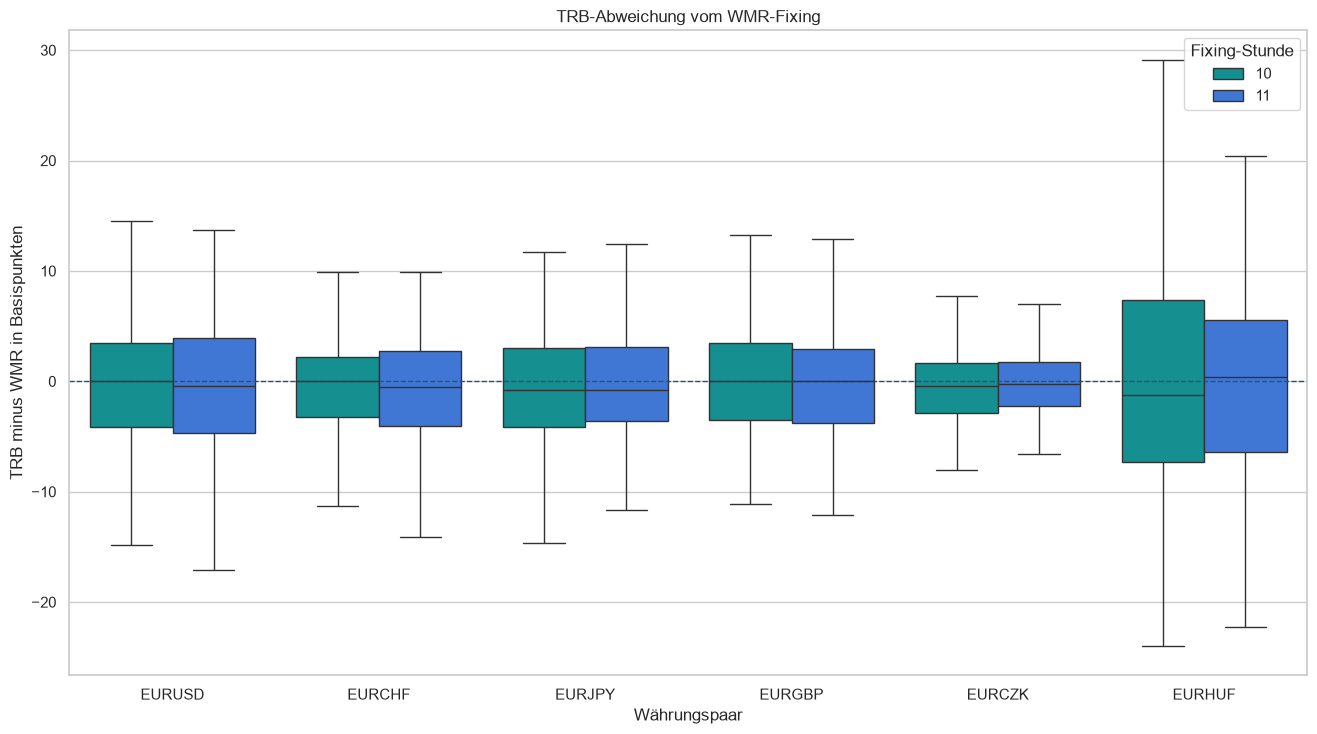

In [137]:
from pathlib import Path

corporate_palette = [
    "#02A3A4",  # Teal
    "#2870ED",  # Bright Blue
    "#245375",  # Stone
    "#FF6130",  # Orange
    "#721C7A",  # Aubergine
    "#0CB43F",  # Apple
    "#028661",  # Forest
    "#EB4C79",  # Pink
]

# Ausgabeordner automatisch erstellen
chart_dir = Path("charts")
chart_dir.mkdir(parents=True, exist_ok=True)

# Einheitliches 16:9-Seitenverhältnis für PowerPoint
fig, ax = plt.subplots(figsize=(13.333, 7.5))

sns.boxplot(
    data=comparison,
    x="Pair",
    y="Difference_bps",
    hue="Hour",
    palette=corporate_palette,
    showfliers=False,
    ax=ax
)

ax.axhline(
    0,
    color="#245375",
    linewidth=1,
    linestyle="--"
)

ax.set_title("TRB-Abweichung vom WMR-Fixing")
ax.set_xlabel("Währungspaar")
ax.set_ylabel("TRB minus WMR in Basispunkten")
ax.legend(title="Fixing-Stunde")

fig.tight_layout()

# Hochauflösendes PNG mit einheitlichen Abmessungen speichern
fig.savefig(
    chart_dir / "trb_abweichung_wmr_fixing.png",
    dpi=300,
    format="png",
    facecolor="white",
    edgecolor="none",
    bbox_inches="tight"
)

plt.show()

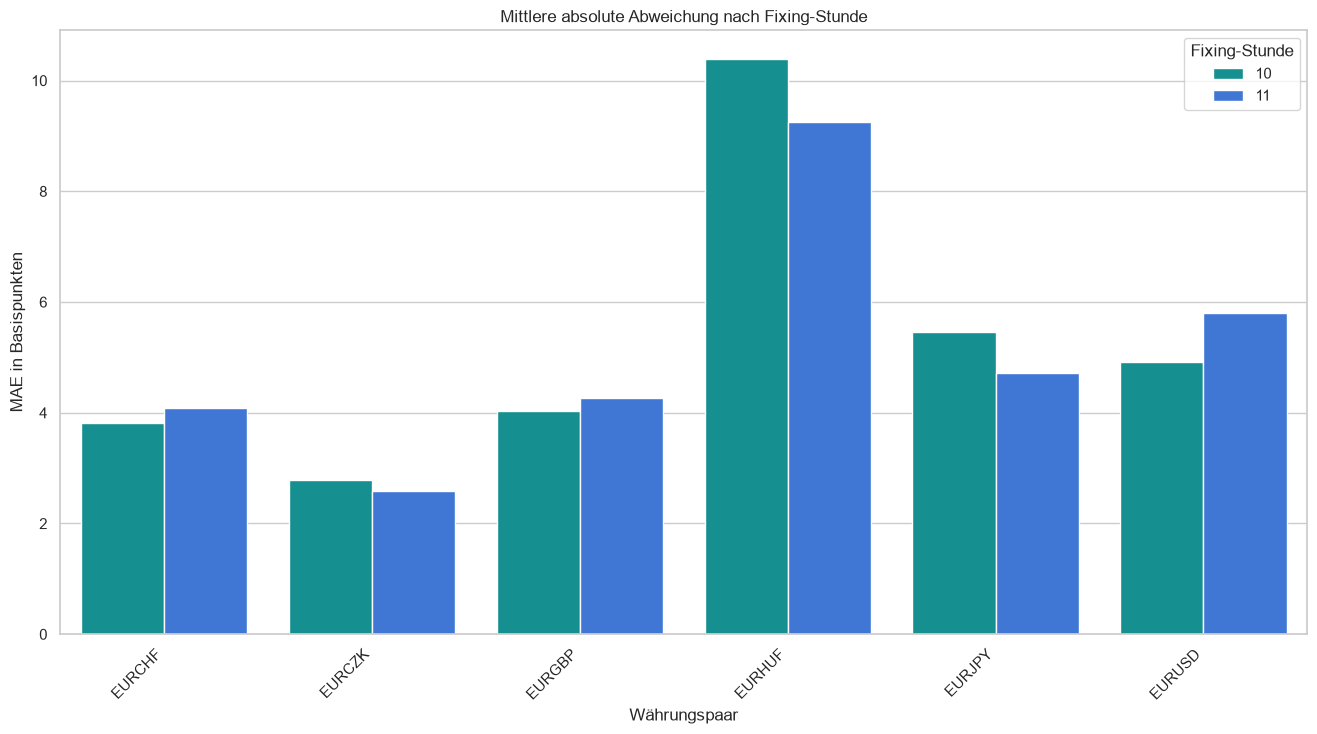

In [138]:
import matplotlib.pyplot as plt
import seaborn as sns

# MAE je Währungspaar und Fixing-Stunde berechnen
mae_chart = (
    comparison
    .groupby(["Pair", "Hour"], as_index=False)
    .agg(
        MAE_bps=("Absolute_Difference_bps", "mean")
    )
)

mae_chart["Hour"] = mae_chart["Hour"].astype(str)

# Chart 10
fig, ax = plt.subplots(figsize=(13.333, 7.5))

sns.barplot(
    data=mae_chart,
    x="Pair",
    y="MAE_bps",
    hue="Hour",
    palette=corporate_palette,
    ax=ax
)

ax.set_title("Mittlere absolute Abweichung nach Fixing-Stunde")
ax.set_xlabel("Währungspaar")
ax.set_ylabel("MAE in Basispunkten")
ax.legend(title="Fixing-Stunde")
ax.tick_params(axis="x", rotation=45)

for label in ax.get_xticklabels():
    label.set_horizontalalignment("right")

fig.tight_layout()

fig.savefig(
    chart_dir / "mae_nach_fixing_stunde.png",
    dpi=300,
    format="png",
    facecolor="white",
    edgecolor="none",
    bbox_inches="tight"
)

plt.show()

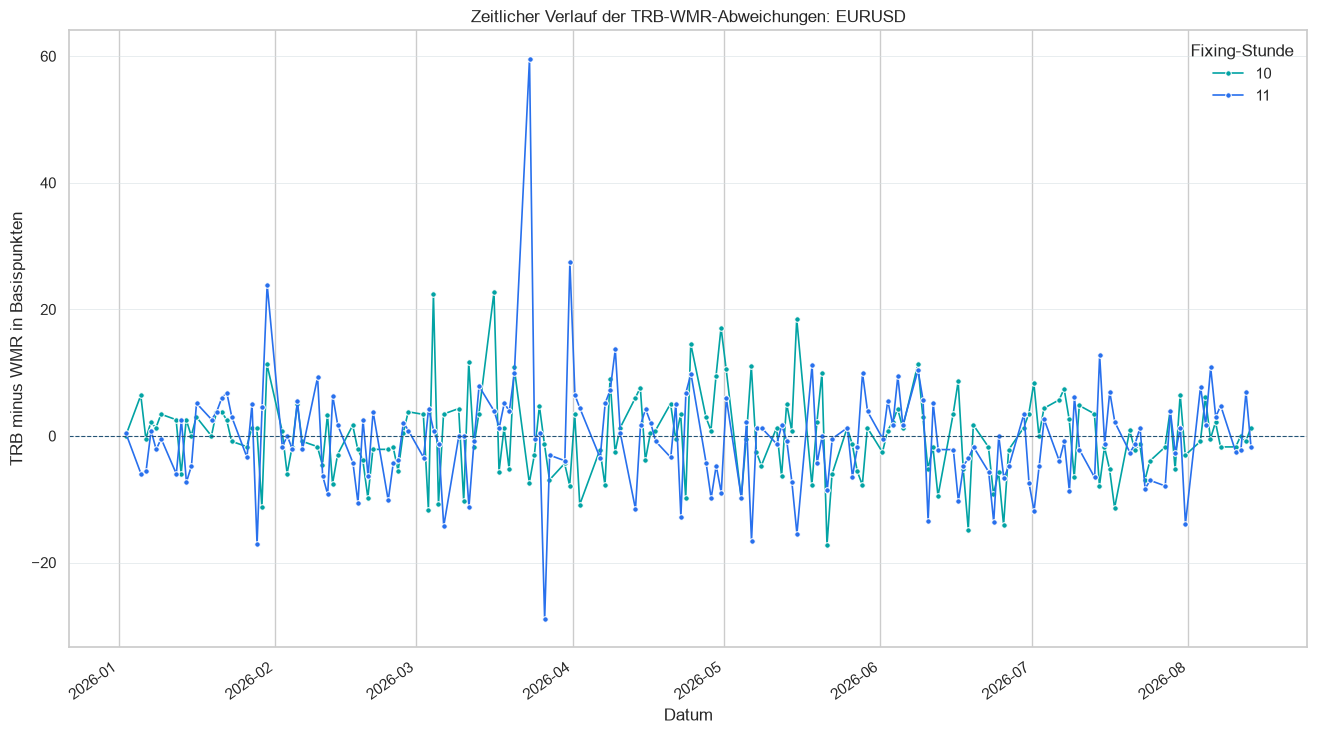

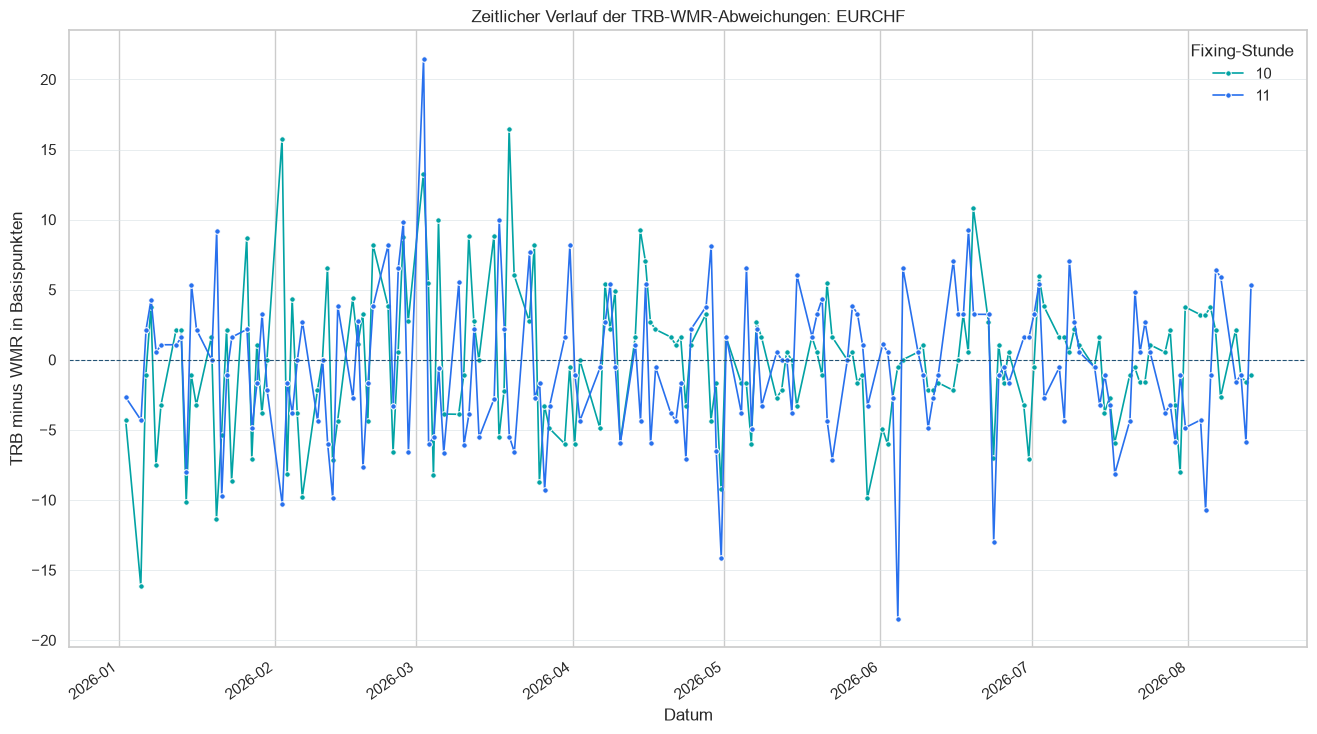

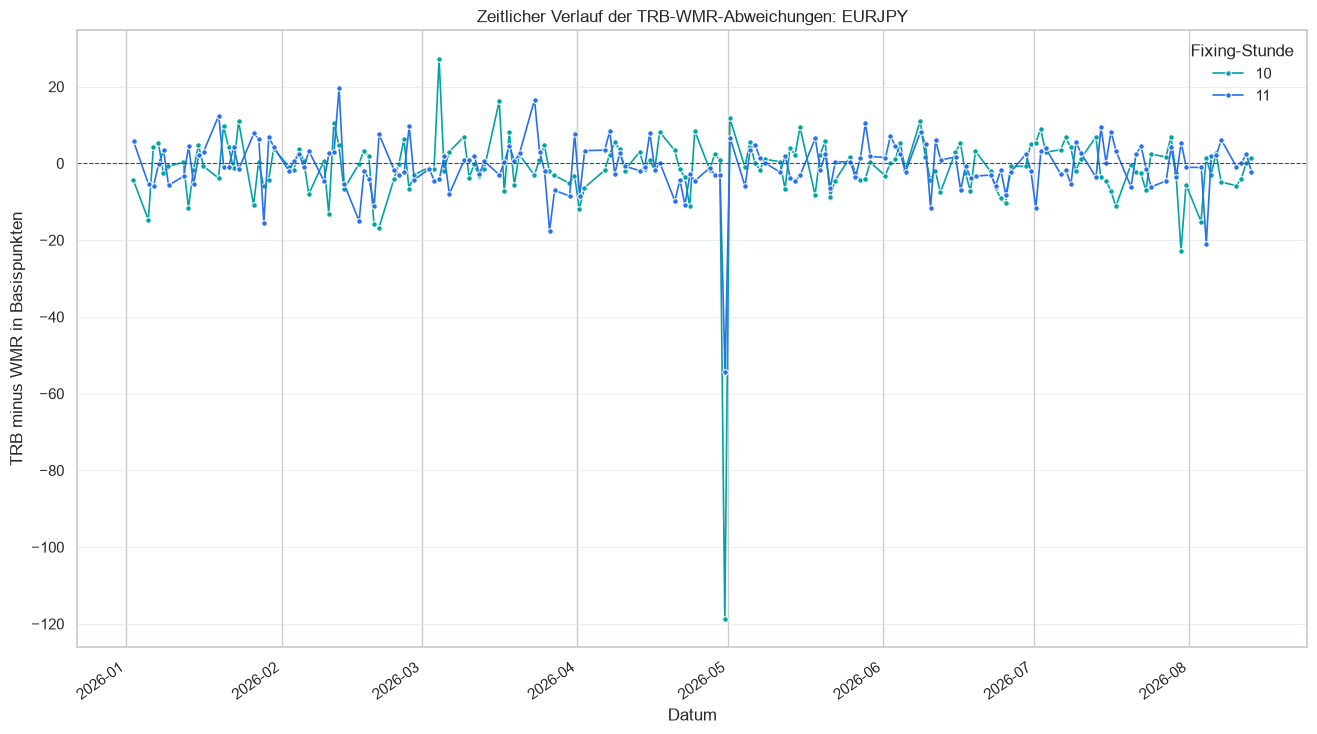

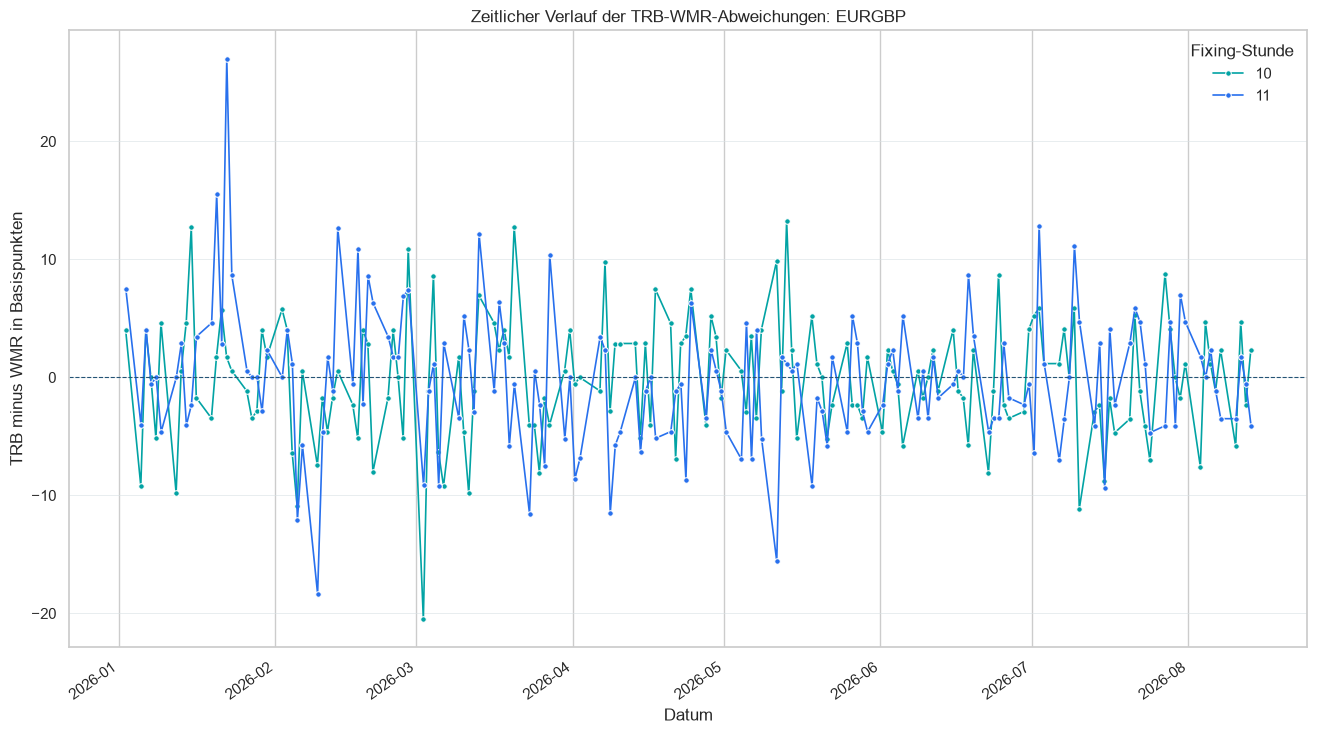

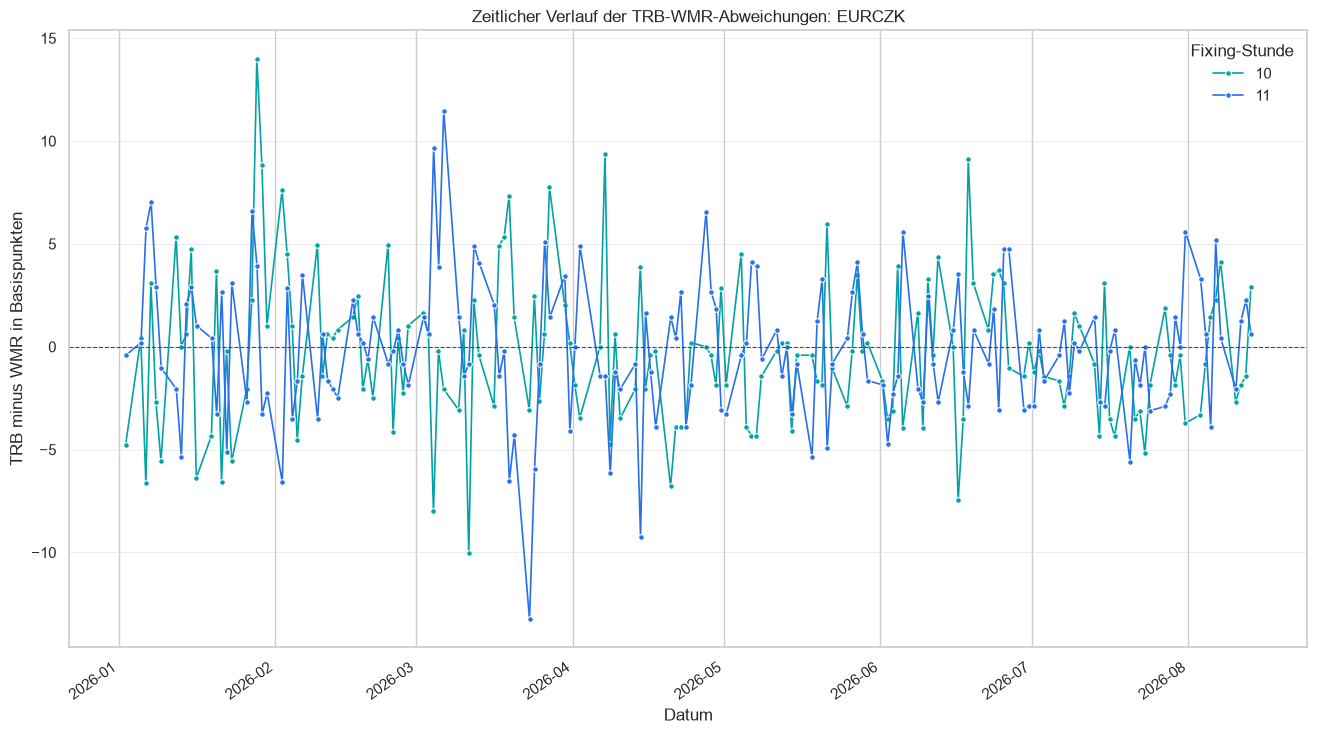

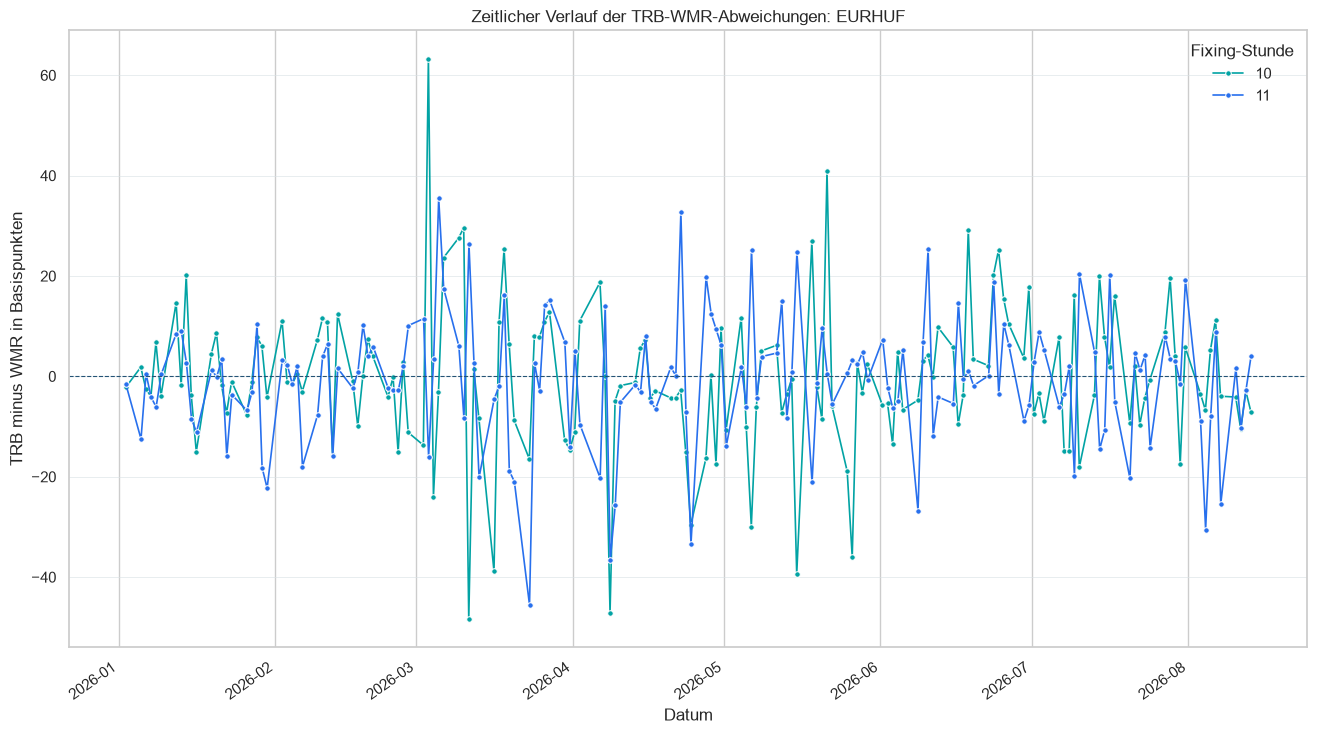

In [139]:
# Je Währungspaar einen separaten Chart erstellen
for pair in comparison["Pair"].dropna().unique():

    pair_data = (
        comparison[comparison["Pair"] == pair]
        .sort_values("Timestamp")
    )

    fig, ax = plt.subplots(figsize=(13.333, 7.5))

    sns.lineplot(
        data=pair_data,
        x="Timestamp",
        y="Difference_bps",
        hue="Hour",
        palette=corporate_palette,
        marker="o",
        markersize=4,
        linewidth=1.2,
        ax=ax
    )

    ax.axhline(
        0,
        color="#245375",
        linewidth=0.8,
        linestyle="--"
    )

    ax.set_title(
        f"Zeitlicher Verlauf der TRB-WMR-Abweichungen: {pair}"
    )
    ax.set_xlabel("Datum")
    ax.set_ylabel("TRB minus WMR in Basispunkten")
    ax.legend(
        title="Fixing-Stunde",
        frameon=False
    )

    ax.grid(
        axis="y",
        color="#D9E1E5",
        linewidth=0.6,
        alpha=0.7
    )

    ax.tick_params(
        axis="x",
        rotation=35
    )

    for label in ax.get_xticklabels():
        label.set_horizontalalignment("right")

    fig.tight_layout()

    # Währungspaar für sicheren Dateinamen bereinigen
    safe_pair_name = (
        str(pair)
        .replace("/", "_")
        .replace("\\", "_")
        .replace(" ", "_")
    )

    fig.savefig(
        chart_dir / f"zeitlicher_verlauf_{safe_pair_name}.png",
        dpi=300,
        format="png",
        facecolor="white",
        edgecolor="none",
        bbox_inches="tight"
    )

    plt.show()
    plt.close(fig)

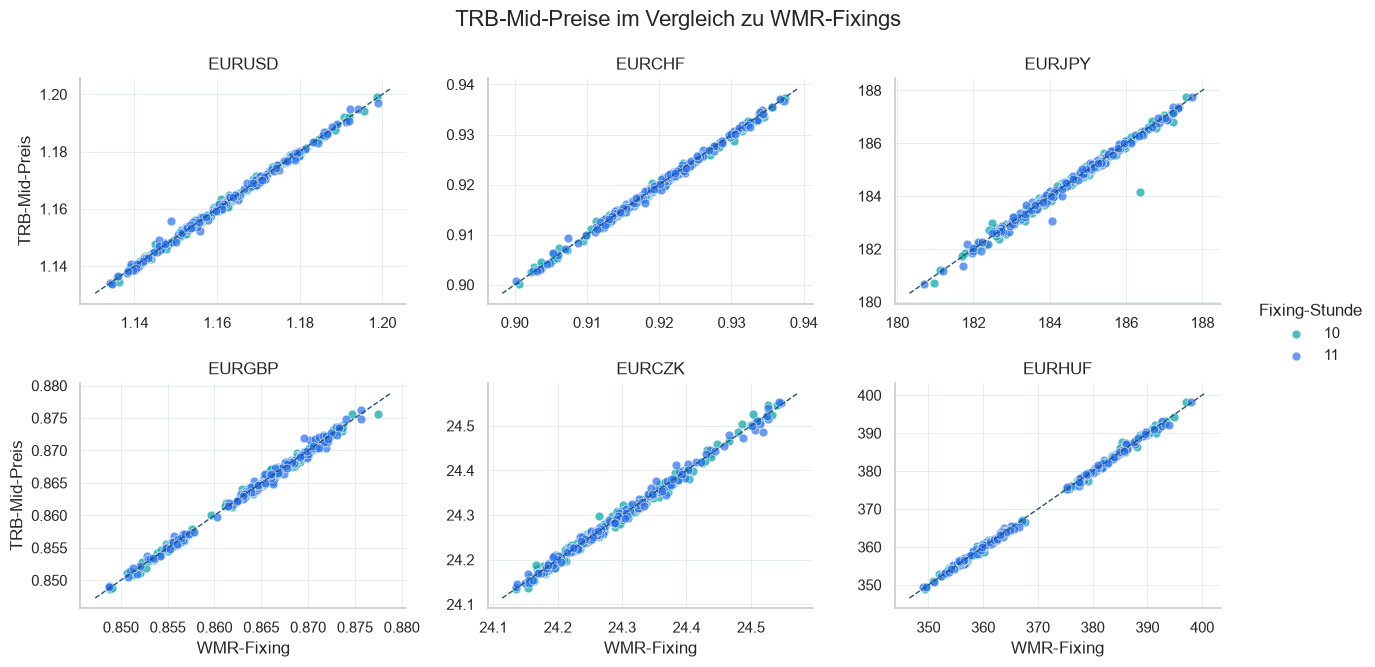

In [140]:
g = sns.FacetGrid(
    data=comparison,
    col="Pair",
    hue="Hour",
    palette=corporate_palette,
    col_wrap=3,
    height=3.4,
    aspect=1.25,
    sharex=False,
    sharey=False
)

g.map_dataframe(
    sns.scatterplot,
    x="WMR",
    y="TRB",
    alpha=0.7,
    s=40
)

# 45-Grad-Referenzlinie je Teilchart
for ax in g.axes.flat:
    low = min(
        ax.get_xlim()[0],
        ax.get_ylim()[0]
    )
    high = max(
        ax.get_xlim()[1],
        ax.get_ylim()[1]
    )

    ax.plot(
        [low, high],
        [low, high],
        color="#245375",
        linestyle="--",
        linewidth=1
    )

    ax.grid(
        color="#D9E1E5",
        linewidth=0.6,
        alpha=0.7
    )

g.add_legend(
    title="Fixing-Stunde"
)

g.set_axis_labels(
    "WMR-Fixing",
    "TRB-Mid-Preis"
)

g.set_titles(
    "{col_name}"
)

g.figure.suptitle(
    "TRB-Mid-Preise im Vergleich zu WMR-Fixings",
    fontsize=16,
    y=0.98
)

# Abstände für Titel, Teilcharts und Legende optimieren
g.figure.subplots_adjust(
    top=0.88,
    bottom=0.10,
    left=0.07,
    right=0.89,
    hspace=0.35,
    wspace=0.25
)

# Hochauflösend als PNG speichern
g.figure.savefig(
    chart_dir / "trb_mid_preise_vs_wmr_fixings.png",
    dpi=300,
    format="png",
    facecolor="white",
    edgecolor="none",
    bbox_inches="tight"
)

plt.show()

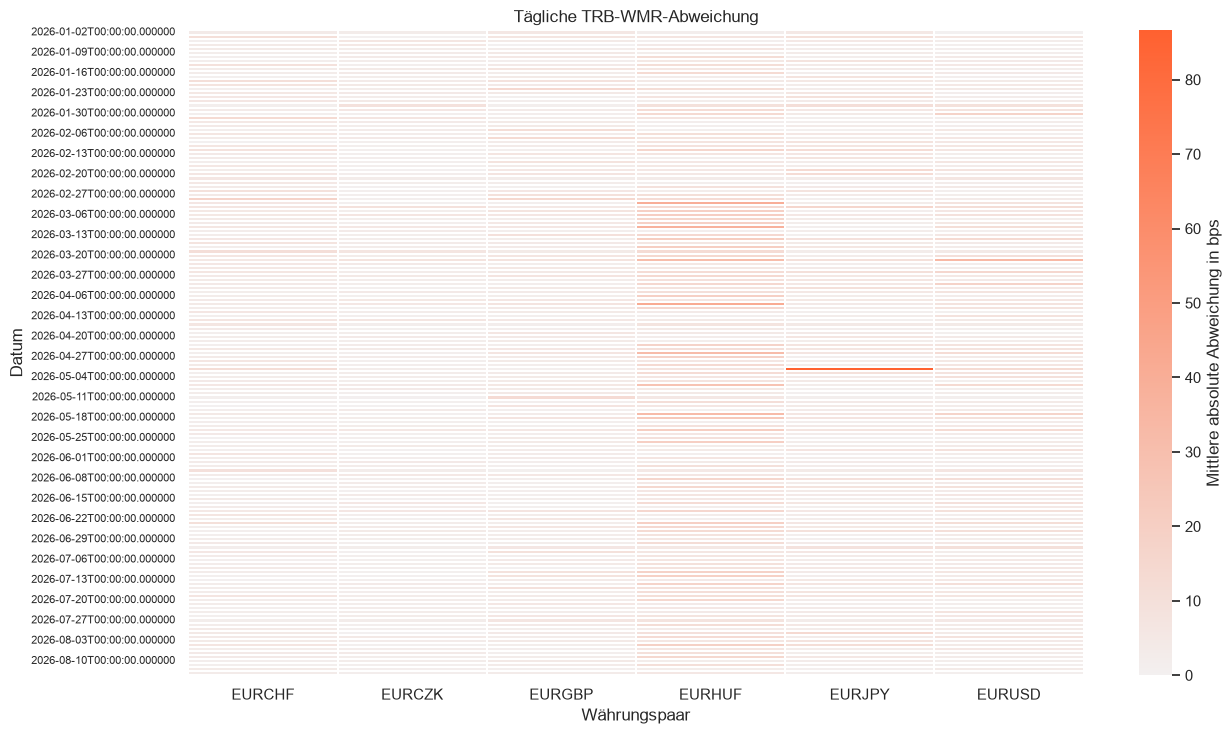

In [141]:
daily_mae = (
    comparison
    .groupby(["Date", "Pair"])["Absolute_Difference_bps"]
    .mean()
    .unstack("Pair")
    .sort_index()
)

# Kontinuierliche Farbskala von Weiß zu Corporate Orange/Red
corporate_heatmap = sns.light_palette(
    "#FF6130",
    as_cmap=True
)

fig, ax = plt.subplots(figsize=(13.333, 7.5))

sns.heatmap(
    daily_mae,
    cmap=corporate_heatmap,
    linewidths=0.2,
    linecolor="white",
    cbar_kws={
        "label": "Mittlere absolute Abweichung in bps"
    },
    ax=ax
)

ax.set_title("Tägliche TRB-WMR-Abweichung")
ax.set_xlabel("Währungspaar")
ax.set_ylabel("Datum")

ax.tick_params(
    axis="x",
    rotation=0
)

ax.tick_params(
    axis="y",
    rotation=0,
    labelsize=8
)

fig.tight_layout()

fig.savefig(
    chart_dir / "taegliche_trb_wmr_abweichung_heatmap.png",
    dpi=300,
    format="png",
    facecolor="white",
    edgecolor="none",
    bbox_inches="tight"
)

plt.show()


In [142]:
largest_outliers = (
    comparison
    .sort_values(
        "Absolute_Difference_bps",
        ascending=False
    )
    [[
        "Timestamp",
        "Hour",
        "Pair",
        "TRB",
        "WMR",
        "Difference",
        "Difference_bps",
        "Absolute_Difference_bps"
    ]]
    .head(20)
)

display(
    largest_outliers.style.format({
        "TRB": "{:.6f}",
        "WMR": "{:.6f}",
        "Difference": "{:.6f}",
        "Difference_bps": "{:.3f}",
        "Absolute_Difference_bps": "{:.3f}"
    })
)


,Timestamp,Hour,Pair,TRB,WMR,Difference,Difference_bps,Absolute_Difference_bps
802,2026-04-30 10:00:00,10,EURJPY,184.145000,186.359850,-2.214850,-118.848,118.848
1674,2026-03-03 10:00:00,10,EURHUF,387.715000,385.275000,2.440000,63.331,63.331
113,2026-03-23 11:00:00,11,EURUSD,1.155650,1.148800,0.006850,59.627,59.627
803,2026-04-30 11:00:00,11,EURJPY,183.050000,184.050500,-1.000500,-54.360,54.360
1686,2026-03-11 10:00:00,10,EURHUF,386.245000,388.125000,-1.880000,-48.438,48.438
1724,2026-04-08 10:00:00,10,EURHUF,377.440000,379.225000,-1.785000,-47.070,47.070
1703,2026-03-23 11:00:00,11,EURHUF,392.230000,394.025000,-1.795000,-45.555,45.555
1786,2026-05-21 10:00:00,10,EURHUF,360.310000,358.840000,1.470000,40.965,40.965
1778,2026-05-15 10:00:00,10,EURHUF,358.680000,360.100000,-1.420000,-39.433,39.433
1692,2026-03-16 10:00:00,10,EURHUF,390.130000,391.650000,-1.520000,-38.810,38.810


In [143]:
volatility_summary = (
    volatility_relation
    .groupby("Pair")
    .apply(
        lambda group: pd.Series({
            "Correlation_Movement_Error": (
                group["Absolute_WMR_Return_bps"]
                .corr(group["Absolute_Difference_bps"])
            )
        }),
        include_groups=False
    )
)

display(volatility_summary.round(3))

,Correlation_Movement_Error
Pair,
EURCHF,0.20300
EURCZK,0.13300
EURGBP,0.21900
EURHUF,0.24300
EURJPY,0.17200
EURUSD,0.16400


In [144]:
overall_summary = pd.Series({
    "Observations": len(comparison),
    "Mean_Bias_bps": comparison["Difference_bps"].mean(),
    "MAE_bps": comparison["Absolute_Difference_bps"].mean(),
    "RMSE_bps": np.sqrt(
        comparison["Squared_Error_bps"].mean()
    ),
    "Median_Absolute_bps": (
        comparison["Absolute_Difference_bps"].median()
    ),
    "P95_Absolute_bps": (
        comparison["Absolute_Difference_bps"].quantile(0.95)
    ),
    "Maximum_Absolute_bps": (
        comparison["Absolute_Difference_bps"].max()
    ),
    "Share_Within_2bps_pct": (
        comparison["Absolute_Difference_bps"]
        .le(2)
        .mean()
        * 100
    )
})

display(
    overall_summary.to_frame("Value").style.format("{:.3f}")
)

,Value
Observations,1908.000
Mean_Bias_bps,-0.412
MAE_bps,5.178
RMSE_bps,8.234
Median_Absolute_bps,3.477
P95_Absolute_bps,15.637
Maximum_Absolute_bps,118.848
Share_Within_2bps_pct,30.084


## 3. Export Tables

This section can be deleted after completion. This is 100% AI generated code to export the tables produced so far as a nicely designed png in order to show them in a quick presentation.

In [145]:
from pathlib import Path
import matplotlib.pyplot as plt

trb_long = df_trb.melt(
    id_vars="Timestamp",
    value_vars=pairs,
    var_name="Pair",
    value_name="TRB"
)

wmr_long = df_wmr.melt(
    id_vars="Timestamp",
    value_vars=pairs,
    var_name="Pair",
    value_name="WMR"
)

comparison = trb_long.merge(
    wmr_long,
    on=["Timestamp", "Pair"],
    how="inner",
    validate="one_to_one"
)

comparison["Date"] = comparison["Timestamp"].dt.normalize()
comparison["Hour"] = comparison["Timestamp"].dt.hour


# Prepare the displayed table without modifying `comparison`
table_data = comparison.head(12).copy()

# Format datetime columns for a cleaner presentation
table_data["Timestamp"] = table_data["Timestamp"].dt.strftime("%Y-%m-%d %H:%M")
table_data["Date"] = table_data["Date"].dt.strftime("%Y-%m-%d")

# Format numeric values consistently
table_data["TRB"] = table_data["TRB"].map(
    lambda value: f"{value:,.6f}" if pd.notna(value) else ""
)
table_data["WMR"] = table_data["WMR"].map(
    lambda value: f"{value:,.6f}" if pd.notna(value) else ""
)

# Create the output directory
tables_dir = Path("tables")
tables_dir.mkdir(parents=True, exist_ok=True)

output_path = tables_dir / "trb_wmr_comparison_preview.png"

# Scale the figure according to the table dimensions
fig_width = max(10, len(table_data.columns) * 1.8)
fig_height = 1.5 + len(table_data) * 0.45

fig, ax = plt.subplots(figsize=(fig_width, fig_height))
ax.axis("off")

ax.set_title(
    "TRB and WMR Comparison: First 12 Observations",
    fontsize=16,
    fontweight="semibold",
    color="#1F2937",
    pad=18,
    loc="left"
)

table = ax.table(
    cellText=table_data.values,
    colLabels=table_data.columns,
    cellLoc="center",
    colLoc="center",
    loc="center",
    bbox=[0, 0, 1, 0.92]
)

table.auto_set_font_size(False)
table.set_fontsize(9.5)
table.auto_set_column_width(col=list(range(len(table_data.columns))))

# Minimalist table styling
for (row, col), cell in table.get_celld().items():
    cell.set_edgecolor("#D1D5DB")
    cell.set_linewidth(0.5)

    if row == 0:
        cell.set_facecolor("#1F4E78")
        cell.set_text_props(
            color="white",
            fontweight="semibold"
        )
        cell.set_height(0.07)
    else:
        cell.set_facecolor("#FFFFFF" if row % 2 else "#F7F9FC")
        cell.set_text_props(color="#1F2937")
        cell.set_height(0.06)

plt.savefig(
    output_path,
    dpi=300,
    bbox_inches="tight",
    facecolor="white",
    pad_inches=0.2
)

plt.close(fig)

print(f"Table exported to: {output_path.resolve()}")

Table exported to: C:\Users\A96IZEB\projects\WMR-Fixing\tables\trb_wmr_comparison_preview.png


In [146]:
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd


# ------------------------------------------------------------------
# 1. Validate and prepare the comparison data
# ------------------------------------------------------------------

required_columns = {"Pair", "TRB", "WMR"}
missing_columns = required_columns.difference(comparison.columns)

if missing_columns:
    raise KeyError(
        "The following required columns are missing from 'comparison': "
        f"{sorted(missing_columns)}"
    )

comparison = comparison.copy()

# Ensure rates are numeric
comparison["TRB"] = pd.to_numeric(
    comparison["TRB"],
    errors="coerce"
)

comparison["WMR"] = pd.to_numeric(
    comparison["WMR"],
    errors="coerce"
)

# Difference expressed in basis points relative to WMR
#
# Example:
# TRB is 0.01% higher than WMR -> Difference_bps = 1.0
comparison["Difference_bps"] = np.where(
    comparison["WMR"].notna() & comparison["WMR"].ne(0),
    ((comparison["TRB"] / comparison["WMR"]) - 1) * 10_000,
    np.nan
)

comparison["Absolute_Difference_bps"] = (
    comparison["Difference_bps"].abs()
)

comparison["Squared_Error_bps"] = (
    comparison["Difference_bps"].pow(2)
)


# ------------------------------------------------------------------
# 2. Calculate summary statistics by pair
# ------------------------------------------------------------------

summary_by_pair = (
    comparison
    .groupby("Pair", observed=True)
    .agg(
        Observations=("Difference_bps", "count"),
        Mean_Bias_bps=("Difference_bps", "mean"),
        Median_Bias_bps=("Difference_bps", "median"),
        MAE_bps=("Absolute_Difference_bps", "mean"),
        Median_AE_bps=("Absolute_Difference_bps", "median"),
        RMSE_bps=(
            "Squared_Error_bps",
            lambda values: np.sqrt(values.mean())
        ),
        Std_bps=("Difference_bps", "std"),
        P95_Absolute_bps=(
            "Absolute_Difference_bps",
            lambda values: values.quantile(0.95)
        ),
        Max_Absolute_bps=("Absolute_Difference_bps", "max"),
        Correlation=(
            "TRB",
            lambda values: values.corr(
                comparison.loc[values.index, "WMR"]
            )
        )
    )
    .sort_values(
        by="MAE_bps",
        ascending=True,
        na_position="last"
    )
)


# ------------------------------------------------------------------
# 3. Prepare a formatted copy for the PNG
# ------------------------------------------------------------------

table_data = (
    summary_by_pair
    .reset_index()
    .rename(
        columns={
            "Mean_Bias_bps": "Mean Bias",
            "Median_Bias_bps": "Median Bias",
            "MAE_bps": "MAE",
            "Median_AE_bps": "Median AE",
            "RMSE_bps": "RMSE",
            "Std_bps": "Std. Dev.",
            "P95_Absolute_bps": "95th Pctl. AE",
            "Max_Absolute_bps": "Maximum AE",
            "Correlation": "Correlation"
        }
    )
    .copy()
)

# Format observation counts
table_data["Observations"] = table_data["Observations"].map(
    lambda value: f"{int(value):,}" if pd.notna(value) else ""
)

# Format basis-point statistics
bps_columns = [
    "Mean Bias",
    "Median Bias",
    "MAE",
    "Median AE",
    "RMSE",
    "Std. Dev.",
    "95th Pctl. AE",
    "Maximum AE"
]

for column in bps_columns:
    table_data[column] = table_data[column].map(
        lambda value: (
            f"{value:,.3f}"
            if pd.notna(value) and np.isfinite(value)
            else ""
        )
    )

# Use additional precision for correlations
table_data["Correlation"] = table_data["Correlation"].map(
    lambda value: (
        f"{value:.6f}"
        if pd.notna(value) and np.isfinite(value)
        else ""
    )
)


# ------------------------------------------------------------------
# 4. Create the output directory and file path
# ------------------------------------------------------------------

tables_dir = Path("tables")
tables_dir.mkdir(parents=True, exist_ok=True)

output_path = tables_dir / "trb_wmr_summary_by_pair.png"


# ------------------------------------------------------------------
# 5. Create a clean, high-resolution table
# ------------------------------------------------------------------

number_of_rows = len(table_data)
number_of_columns = len(table_data.columns)

fig_width = max(18, number_of_columns * 1.65)
fig_height = max(4.5, 2.2 + number_of_rows * 0.48)

fig, ax = plt.subplots(
    figsize=(fig_width, fig_height)
)

fig.patch.set_facecolor("white")
ax.set_facecolor("white")
ax.axis("off")

# Main title
ax.text(
    0,
    1.03,
    "TRB vs. WMR Accuracy Summary by Currency Pair",
    transform=ax.transAxes,
    fontsize=18,
    fontweight="semibold",
    color="#1F2937",
    ha="left",
    va="bottom"
)

# Subtitle
ax.text(
    0,
    0.975,
    "Currency pairs ranked from lowest to highest mean absolute error",
    transform=ax.transAxes,
    fontsize=10.5,
    color="#6B7280",
    ha="left",
    va="bottom"
)

# Create the table
table = ax.table(
    cellText=table_data.values,
    colLabels=table_data.columns,
    cellLoc="center",
    colLoc="center",
    loc="center",
    bbox=[0, 0, 1, 0.92]
)

table.auto_set_font_size(False)
table.set_fontsize(9.5)

table.auto_set_column_width(
    col=list(range(number_of_columns))
)


# ------------------------------------------------------------------
# 6. Apply minimalist styling
# ------------------------------------------------------------------

for (row, column), cell in table.get_celld().items():

    cell.set_edgecolor("#D1D5DB")
    cell.set_linewidth(0.5)

    if row == 0:
        # Header row
        cell.set_facecolor("#1F4E78")
        cell.set_text_props(
            color="white",
            fontweight="semibold"
        )
        cell.set_height(0.075)

    else:
        # Alternating row colors
        if row % 2 == 0:
            cell.set_facecolor("#F7F9FC")
        else:
            cell.set_facecolor("#FFFFFF")

        cell.set_text_props(
            color="#1F2937"
        )
        cell.set_height(0.065)

        # Left-align and emphasize the pair names
        if column == 0:
            cell.set_text_props(
                color="#1F2937",
                fontweight="semibold",
                ha="left"
            )

        # Highlight the MAE column subtly
        if table_data.columns[column] == "MAE":
            cell.set_facecolor(
                "#EAF2F8" if row % 2 else "#E1ECF4"
            )
            cell.set_text_props(
                color="#1F4E78",
                fontweight="semibold"
            )


# ------------------------------------------------------------------
# 7. Export the table as a high-resolution PNG
# ------------------------------------------------------------------

fig.savefig(
    output_path,
    dpi=300,
    bbox_inches="tight",
    facecolor="white",
    edgecolor="none",
    pad_inches=0.25
)

plt.close(fig)

print(f"Table exported successfully to: {output_path.resolve()}")


# Optional notebook display of the numeric summary
display(
    summary_by_pair.style.format({
        "Mean_Bias_bps": "{:.3f}",
        "Median_Bias_bps": "{:.3f}",
        "MAE_bps": "{:.3f}",
        "Median_AE_bps": "{:.3f}",
        "RMSE_bps": "{:.3f}",
        "Std_bps": "{:.3f}",
        "P95_Absolute_bps": "{:.3f}",
        "Max_Absolute_bps": "{:.3f}",
        "Correlation": "{:.6f}"
    })
)

Table exported successfully to: C:\Users\A96IZEB\projects\WMR-Fixing\tables\trb_wmr_summary_by_pair.png


,Observations,Mean_Bias_bps,Median_Bias_bps,MAE_bps,Median_AE_bps,RMSE_bps,Std_bps,P95_Absolute_bps,Max_Absolute_bps,Correlation
Pair,,,,,,,,,,
EURCZK,318,-0.222,-0.410,2.689,2.159,3.522,3.521,6.635,14.013,0.995968
EURCHF,318,-0.390,-0.540,3.950,3.241,5.177,5.171,9.865,21.490,0.998166
EURGBP,318,-0.124,0.000,4.149,3.464,5.475,5.482,10.968,27.024,0.996939
EURJPY,318,-1.041,-0.804,5.091,3.376,9.540,9.498,12.576,118.848,0.992310
EURUSD,318,-0.111,0.000,5.367,3.931,7.709,7.720,13.937,59.627,0.998183
EURHUF,318,-0.583,-0.698,9.821,6.745,13.681,13.690,29.201,63.331,0.999244


In [147]:
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd


# ==================================================================
# 1. Validate the input DataFrame
# ==================================================================

required_base_columns = {
    "Pair",
    "TRB",
    "WMR"
}

missing_base_columns = required_base_columns.difference(
    comparison.columns
)

if missing_base_columns:
    raise KeyError(
        "The following required columns are missing from "
        f"'comparison': {sorted(missing_base_columns)}"
    )


# Work on a copy to avoid unintended modifications
comparison = comparison.copy()


# ==================================================================
# 2. Ensure TRB and WMR are numeric
# ==================================================================

comparison["TRB"] = pd.to_numeric(
    comparison["TRB"],
    errors="coerce"
)

comparison["WMR"] = pd.to_numeric(
    comparison["WMR"],
    errors="coerce"
)


# ==================================================================
# 3. Create the Hour column if it does not already exist
# ==================================================================

if "Hour" not in comparison.columns:

    if "Timestamp" not in comparison.columns:
        raise KeyError(
            "'comparison' must contain either an 'Hour' column "
            "or a 'Timestamp' column from which Hour can be derived."
        )

    comparison["Timestamp"] = pd.to_datetime(
        comparison["Timestamp"],
        errors="coerce"
    )

    comparison["Hour"] = comparison["Timestamp"].dt.hour


# Convert Hour to a nullable integer column
comparison["Hour"] = pd.to_numeric(
    comparison["Hour"],
    errors="coerce"
).astype("Int64")


# ==================================================================
# 4. Create the basis-point error columns
# ==================================================================

# Relative difference between TRB and WMR in basis points:
#
# 1 basis point = 0.01%
#
# A result of 1.000 means that TRB is approximately
# one basis point above WMR.
comparison["Difference_bps"] = np.where(
    comparison["WMR"].notna()
    & comparison["WMR"].ne(0)
    & comparison["TRB"].notna(),
    (
        (comparison["TRB"] / comparison["WMR"]) - 1
    ) * 10_000,
    np.nan
)

comparison["Absolute_Difference_bps"] = (
    comparison["Difference_bps"].abs()
)

comparison["Squared_Error_bps"] = (
    comparison["Difference_bps"].pow(2)
)


# ==================================================================
# 5. Create the pair-and-hour summary
# ==================================================================

summary_by_pair_hour = (
    comparison
    .dropna(
        subset=[
            "Pair",
            "Hour"
        ]
    )
    .groupby(
        ["Pair", "Hour"],
        observed=True,
        sort=True
    )
    .agg(
        Observations=(
            "Difference_bps",
            "count"
        ),
        Mean_Bias_bps=(
            "Difference_bps",
            "mean"
        ),
        MAE_bps=(
            "Absolute_Difference_bps",
            "mean"
        ),
        RMSE_bps=(
            "Squared_Error_bps",
            lambda values: np.sqrt(values.mean())
        ),
        P95_Absolute_bps=(
            "Absolute_Difference_bps",
            lambda values: values.quantile(0.95)
        ),
        Max_Absolute_bps=(
            "Absolute_Difference_bps",
            "max"
        )
    )
    .reset_index()
    .sort_values(
        by=[
            "Pair",
            "Hour"
        ],
        ascending=[
            True,
            True
        ],
        na_position="last"
    )
    .reset_index(drop=True)
)


# Check that the summary contains data
if summary_by_pair_hour.empty:
    raise ValueError(
        "The pair-and-hour summary is empty. Check whether "
        "'comparison' contains valid Pair, Hour, TRB, and WMR values."
    )


# ==================================================================
# 6. Display the numeric summary in the notebook
# ==================================================================

display(
    summary_by_pair_hour.style
    .format({
        "Hour": lambda value: (
            f"{int(value):02d}:00"
            if pd.notna(value)
            else ""
        ),
        "Observations": "{:,.0f}",
        "Mean_Bias_bps": "{:.3f}",
        "MAE_bps": "{:.3f}",
        "RMSE_bps": "{:.3f}",
        "P95_Absolute_bps": "{:.3f}",
        "Max_Absolute_bps": "{:.3f}"
    })
    .hide(axis="index")
)


# ==================================================================
# 7. Prepare a separate formatted copy for the PNG
# ==================================================================

table_data = (
    summary_by_pair_hour
    .rename(
        columns={
            "Mean_Bias_bps": "Mean Bias",
            "MAE_bps": "MAE",
            "RMSE_bps": "RMSE",
            "P95_Absolute_bps": "95th Pctl. AE",
            "Max_Absolute_bps": "Maximum AE"
        }
    )
    .copy()
)


# Format the hour as HH:00
table_data["Hour"] = table_data["Hour"].map(
    lambda value: (
        f"{int(value):02d}:00"
        if pd.notna(value)
        else ""
    )
)


# Format observation counts
table_data["Observations"] = table_data[
    "Observations"
].map(
    lambda value: (
        f"{int(value):,}"
        if pd.notna(value)
        else ""
    )
)


# Format all basis-point columns
bps_columns = [
    "Mean Bias",
    "MAE",
    "RMSE",
    "95th Pctl. AE",
    "Maximum AE"
]

for column in bps_columns:
    table_data[column] = table_data[column].map(
        lambda value: (
            f"{value:,.3f}"
            if pd.notna(value) and np.isfinite(value)
            else ""
        )
    )


# ==================================================================
# 8. Create the tables directory and output path
# ==================================================================

tables_dir = Path("tables")

tables_dir.mkdir(
    parents=True,
    exist_ok=True
)

output_path = (
    tables_dir
    / "trb_wmr_summary_by_pair_and_hour.png"
)


# ==================================================================
# 9. Determine the figure dimensions
# ==================================================================

number_of_rows = len(table_data)
number_of_columns = len(table_data.columns)

# Width depends mainly on the number of columns
fig_width = max(
    14,
    number_of_columns * 1.75
)

# Height grows with the number of rows
fig_height = max(
    5,
    2.4 + number_of_rows * 0.38
)


# ==================================================================
# 10. Create the figure
# ==================================================================

fig, ax = plt.subplots(
    figsize=(
        fig_width,
        fig_height
    )
)

fig.patch.set_facecolor("white")
ax.set_facecolor("white")
ax.axis("off")


# Main title
ax.text(
    0,
    1.035,
    "TRB vs. WMR Accuracy by Currency Pair and Hour",
    transform=ax.transAxes,
    fontsize=18,
    fontweight="semibold",
    color="#1F2937",
    horizontalalignment="left",
    verticalalignment="bottom"
)


# Subtitle
ax.text(
    0,
    0.985,
    "Hourly comparison statistics, expressed in basis points",
    transform=ax.transAxes,
    fontsize=10.5,
    color="#6B7280",
    horizontalalignment="left",
    verticalalignment="bottom"
)


# ==================================================================
# 11. Add the table
# ==================================================================

table = ax.table(
    cellText=table_data.values,
    colLabels=table_data.columns,
    cellLoc="center",
    colLoc="center",
    loc="center",
    bbox=[
        0,
        0,
        1,
        0.94
    ]
)

table.auto_set_font_size(False)
table.set_fontsize(9.5)

table.auto_set_column_width(
    col=list(
        range(number_of_columns)
    )
)


# ==================================================================
# 12. Identify pair groups for alternating colors
# ==================================================================

unique_pairs = (
    table_data["Pair"]
    .drop_duplicates()
    .tolist()
)

pair_color_position = {
    pair: position
    for position, pair in enumerate(unique_pairs)
}


# ==================================================================
# 13. Apply clean, minimalist styling
# ==================================================================

for row in range(number_of_rows + 1):

    for column in range(number_of_columns):

        cell = table[row, column]

        cell.set_edgecolor("#D1D5DB")
        cell.set_linewidth(0.5)

        # ----------------------------------------------------------
        # Header row
        # ----------------------------------------------------------

        if row == 0:

            cell.set_facecolor("#1F4E78")

            cell.set_text_props(
                color="white",
                fontweight="semibold",
                horizontalalignment="center"
            )

            cell.set_height(0.06)

            continue

        # ----------------------------------------------------------
        # Data rows
        # ----------------------------------------------------------

        current_pair = table_data.iloc[row - 1]["Pair"]

        pair_position = pair_color_position[
            current_pair
        ]

        # Use alternating colors for complete pair groups
        if pair_position % 2 == 0:
            regular_row_color = "#FFFFFF"
            mae_row_color = "#EAF2F8"
        else:
            regular_row_color = "#F7F9FC"
            mae_row_color = "#E1ECF4"

        cell.set_facecolor(
            regular_row_color
        )

        cell.set_text_props(
            color="#1F2937",
            horizontalalignment="center"
        )

        cell.set_height(0.045)

        # Left-align and emphasize currency-pair labels
        if column == 0:
            cell.set_text_props(
                color="#1F2937",
                fontweight="semibold",
                horizontalalignment="left"
            )

        # Subtly highlight the MAE column
        if table_data.columns[column] == "MAE":
            cell.set_facecolor(
                mae_row_color
            )

            cell.set_text_props(
                color="#1F4E78",
                fontweight="semibold",
                horizontalalignment="center"
            )

        # Add a stronger top border at the beginning of each pair
        is_first_row_of_pair = (
            row == 1
            or table_data.iloc[row - 2]["Pair"]
            != current_pair
        )

        if is_first_row_of_pair:
            cell.set_edgecolor("#94A3B8")
            cell.set_linewidth(1.1)


# ==================================================================
# 14. Save the table as a high-resolution PNG
# ==================================================================

fig.savefig(
    output_path,
    dpi=300,
    bbox_inches="tight",
    facecolor="white",
    edgecolor="none",
    pad_inches=0.25
)

plt.close(fig)


# ==================================================================
# 15. Confirm the export
# ==================================================================

print(
    "Table exported successfully to:"
)

print(
    output_path.resolve()
)

Pair,Hour,Observations,Mean_Bias_bps,MAE_bps,RMSE_bps,P95_Absolute_bps,Max_Absolute_bps
EURCHF,10:00,159,-0.227,3.815,5.072,9.874,16.461
EURCHF,11:00,159,-0.552,4.085,5.280,9.850,21.490
EURCZK,10:00,159,-0.297,2.794,3.656,7.469,14.013
EURCZK,11:00,159,-0.146,2.584,3.383,6.533,13.255
EURGBP,10:00,159,-0.104,4.024,5.127,9.825,20.514
EURGBP,11:00,159,-0.143,4.273,5.803,11.601,27.024
EURHUF,10:00,159,-0.366,10.385,14.630,29.674,63.331
EURHUF,11:00,159,-0.801,9.256,12.661,25.618,45.555
EURJPY,10:00,159,-1.436,5.457,11.392,13.379,118.848
EURJPY,11:00,159,-0.646,4.725,7.228,11.731,54.360


Table exported successfully to:
C:\Users\A96IZEB\projects\WMR-Fixing\tables\trb_wmr_summary_by_pair_and_hour.png


In [148]:
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from IPython.display import display


# =====================================================================
# 1. Validate the comparison DataFrame
# =====================================================================

required_columns = {
    "Pair",
    "TRB",
    "WMR"
}

missing_columns = required_columns.difference(comparison.columns)

if missing_columns:
    raise KeyError(
        "The following required columns are missing from 'comparison': "
        f"{sorted(missing_columns)}"
    )


# Work on a copy so the original DataFrame is not modified unexpectedly
comparison = comparison.copy()


# =====================================================================
# 2. Ensure that TRB and WMR are numeric
# =====================================================================

comparison["TRB"] = pd.to_numeric(
    comparison["TRB"],
    errors="coerce"
)

comparison["WMR"] = pd.to_numeric(
    comparison["WMR"],
    errors="coerce"
)


# =====================================================================
# 3. Create the Hour column if necessary
# =====================================================================

if "Hour" not in comparison.columns:

    if "Timestamp" not in comparison.columns:
        raise KeyError(
            "'comparison' must contain either an 'Hour' column or "
            "a 'Timestamp' column from which Hour can be derived."
        )

    comparison["Timestamp"] = pd.to_datetime(
        comparison["Timestamp"],
        errors="coerce"
    )

    comparison["Hour"] = comparison["Timestamp"].dt.hour


comparison["Hour"] = pd.to_numeric(
    comparison["Hour"],
    errors="coerce"
).astype("Int64")


# =====================================================================
# 4. Create the required error columns
# =====================================================================

# Relative difference between TRB and WMR in basis points.
#
# Example:
# Difference_bps = 1 means that TRB is approximately
# one basis point higher than WMR.
comparison["Difference_bps"] = np.where(
    comparison["TRB"].notna()
    & comparison["WMR"].notna()
    & comparison["WMR"].ne(0),
    (
        (comparison["TRB"] / comparison["WMR"]) - 1
    ) * 10_000,
    np.nan
)

comparison["Absolute_Difference_bps"] = (
    comparison["Difference_bps"].abs()
)

comparison["Squared_Error_bps"] = (
    comparison["Difference_bps"].pow(2)
)


# =====================================================================
# 5. Create the summary by currency pair and hour
# =====================================================================

summary_by_pair_hour = (
    comparison
    .dropna(
        subset=[
            "Pair",
            "Hour"
        ]
    )
    .groupby(
        [
            "Pair",
            "Hour"
        ],
        observed=True,
        sort=True
    )
    .agg(
        Observations=(
            "Difference_bps",
            "count"
        ),
        Mean_Bias_bps=(
            "Difference_bps",
            "mean"
        ),
        MAE_bps=(
            "Absolute_Difference_bps",
            "mean"
        ),
        RMSE_bps=(
            "Squared_Error_bps",
            lambda values: np.sqrt(values.mean())
        ),
        P95_Absolute_bps=(
            "Absolute_Difference_bps",
            lambda values: values.quantile(0.95)
        ),
        Max_Absolute_bps=(
            "Absolute_Difference_bps",
            "max"
        )
    )
    .reset_index()
    .sort_values(
        by=[
            "Pair",
            "Hour"
        ]
    )
    .reset_index(drop=True)
)


if summary_by_pair_hour.empty:
    raise ValueError(
        "The hourly summary is empty. Check whether 'comparison' contains "
        "valid Pair, Hour, TRB, and WMR values."
    )


# =====================================================================
# 6. Create the hourly pivot table
# =====================================================================

metrics = [
    "Mean_Bias_bps",
    "MAE_bps",
    "RMSE_bps",
    "P95_Absolute_bps"
]

hour_comparison = (
    summary_by_pair_hour
    .pivot(
        index="Pair",
        columns="Hour",
        values=metrics
    )
)


# Preserve the desired metric order and sort hours chronologically
available_hours = sorted(
    summary_by_pair_hour["Hour"]
    .dropna()
    .astype(int)
    .unique()
    .tolist()
)

ordered_columns = [
    (metric, hour)
    for metric in metrics
    for hour in available_hours
    if (metric, hour) in hour_comparison.columns
]

hour_comparison = hour_comparison.reindex(
    columns=pd.MultiIndex.from_tuples(
        ordered_columns,
        names=[
            "Metric",
            "Hour"
        ]
    )
)

hour_comparison = hour_comparison.sort_index()


# =====================================================================
# 7. Display the numeric pivot table in the notebook
# =====================================================================

display(
    hour_comparison
    .round(3)
    .style
    .format(
        "{:,.3f}",
        na_rep=""
    )
)


# =====================================================================
# 8. Prepare a formatted copy for the PNG
# =====================================================================

table_data = hour_comparison.copy()

metric_names = {
    "Mean_Bias_bps": "Mean Bias",
    "MAE_bps": "MAE",
    "RMSE_bps": "RMSE",
    "P95_Absolute_bps": "95th Pctl. AE"
}


# Flatten the multi-level column names
table_data.columns = [
    f"{metric_names[metric]} | {int(hour):02d}:00"
    for metric, hour in table_data.columns
]


# Move Pair from the index into the first visible column
table_data = (
    table_data
    .reset_index()
    .copy()
)


# Format all values for presentation
for column in table_data.columns:

    if column == "Pair":
        table_data[column] = table_data[column].astype(str)

    else:
        table_data[column] = table_data[column].map(
            lambda value: (
                f"{value:,.3f}"
                if pd.notna(value) and np.isfinite(value)
                else ""
            )
        )


# =====================================================================
# 9. Create the output directory
# =====================================================================

tables_dir = Path("tables")

tables_dir.mkdir(
    parents=True,
    exist_ok=True
)

output_path = (
    tables_dir
    / "trb_wmr_hourly_metric_comparison.png"
)


# =====================================================================
# 10. Determine the required figure dimensions
# =====================================================================

number_of_rows = len(table_data)
number_of_columns = len(table_data.columns)

# This pivot can be very wide because every metric-hour combination
# becomes a separate column.
fig_width = max(
    18,
    2.6 + (number_of_columns - 1) * 1.3
)

fig_height = max(
    5,
    2.6 + number_of_rows * 0.55
)


# =====================================================================
# 11. Create the figure
# =====================================================================

fig, ax = plt.subplots(
    figsize=(
        fig_width,
        fig_height
    )
)

fig.patch.set_facecolor("white")
ax.set_facecolor("white")
ax.axis("off")


# Main title
ax.text(
    0,
    1.045,
    "TRB vs. WMR Hourly Error Comparison",
    transform=ax.transAxes,
    fontsize=18,
    fontweight="semibold",
    color="#1F2937",
    ha="left",
    va="bottom"
)


# Subtitle
ax.text(
    0,
    0.992,
    (
        "Mean bias, MAE, RMSE and 95th-percentile absolute error "
        "by currency pair and hour"
    ),
    transform=ax.transAxes,
    fontsize=10.5,
    color="#6B7280",
    ha="left",
    va="bottom"
)


# =====================================================================
# 12. Create the table
# =====================================================================

table = ax.table(
    cellText=table_data.values,
    colLabels=table_data.columns,
    cellLoc="center",
    colLoc="center",
    loc="center",
    bbox=[
        0,
        0,
        1,
        0.94
    ]
)

table.auto_set_font_size(False)


# Reduce the font size as the table becomes wider
if number_of_columns <= 12:
    font_size = 9.0
elif number_of_columns <= 24:
    font_size = 8.0
elif number_of_columns <= 40:
    font_size = 7.0
else:
    font_size = 6.0

table.set_fontsize(font_size)

table.auto_set_column_width(
    col=list(
        range(number_of_columns)
    )
)


# =====================================================================
# 13. Define the metric colors
# =====================================================================

header_colors = {
    "Mean Bias": "#1F4E78",
    "MAE": "#2E6F95",
    "RMSE": "#357A73",
    "95th Pctl. AE": "#556B8D"
}

body_colors = {
    "Mean Bias": "#F1F6FA",
    "MAE": "#EAF2F8",
    "RMSE": "#EDF6F4",
    "95th Pctl. AE": "#F1F3F8"
}


# =====================================================================
# 14. Style the table
# =====================================================================

for row in range(number_of_rows + 1):

    for column in range(number_of_columns):

        cell = table[row, column]
        column_name = table_data.columns[column]

        cell.set_edgecolor("#D1D5DB")
        cell.set_linewidth(0.5)

        # -------------------------------------------------------------
        # Header row
        # -------------------------------------------------------------

        if row == 0:

            if column_name == "Pair":
                header_color = "#1F2937"
            else:
                metric_name = column_name.split(" | ")[0]

                header_color = header_colors.get(
                    metric_name,
                    "#1F4E78"
                )

            cell.set_facecolor(header_color)

            cell.set_text_props(
                color="white",
                fontweight="semibold",
                ha="center",
                va="center"
            )

            cell.set_height(0.085)

            continue

        # -------------------------------------------------------------
        # Pair column
        # -------------------------------------------------------------

        if column_name == "Pair":

            pair_background = (
                "#FFFFFF"
                if row % 2 == 1
                else "#F7F9FC"
            )

            cell.set_facecolor(pair_background)

            cell.set_text_props(
                color="#1F2937",
                fontweight="semibold",
                ha="left",
                va="center"
            )

            cell.set_height(0.065)

            continue

        # -------------------------------------------------------------
        # Metric columns
        # -------------------------------------------------------------

        metric_name = column_name.split(" | ")[0]

        metric_background = body_colors.get(
            metric_name,
            "#FFFFFF"
        )

        # Alternate between white and the light metric color
        if row % 2 == 1:
            cell.set_facecolor("#FFFFFF")
        else:
            cell.set_facecolor(metric_background)

        cell.set_text_props(
            color="#1F2937",
            ha="center",
            va="center"
        )

        cell.set_height(0.065)

        # Add a stronger vertical separator before every new metric
        if column == 1:
            is_new_metric_group = True

        else:
            previous_column_name = table_data.columns[
                column - 1
            ]

            if previous_column_name == "Pair":
                previous_metric_name = None
            else:
                previous_metric_name = (
                    previous_column_name.split(" | ")[0]
                )

            is_new_metric_group = (
                previous_metric_name != metric_name
            )

        if is_new_metric_group:
            cell.set_edgecolor("#94A3B8")
            cell.set_linewidth(1.2)


# =====================================================================
# 15. Export the table as a high-resolution PNG
# =====================================================================

fig.savefig(
    output_path,
    dpi=300,
    bbox_inches="tight",
    facecolor="white",
    edgecolor="none",
    pad_inches=0.25
)

plt.close(fig)


# =====================================================================
# 16. Confirm that the file was created
# =====================================================================

if not output_path.exists():
    raise FileNotFoundError(
        f"The PNG export was not created at: {output_path.resolve()}"
    )

print("Table exported successfully to:")
print(output_path.resolve())

Table exported successfully to:
C:\Users\A96IZEB\projects\WMR-Fixing\tables\trb_wmr_hourly_metric_comparison.png


In [149]:
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd


# ------------------------------------------------------------------
# 1. Validate and prepare the comparison data
# ------------------------------------------------------------------

comparison = comparison.copy()

required_columns = {"Pair"}
missing_columns = required_columns.difference(comparison.columns)

if missing_columns:
    raise KeyError(
        "The following required columns are missing from 'comparison': "
        f"{sorted(missing_columns)}"
    )


# Recreate Difference_bps if it does not already exist
if "Difference_bps" not in comparison.columns:

    required_rate_columns = {"TRB", "WMR"}
    missing_rate_columns = required_rate_columns.difference(
        comparison.columns
    )

    if missing_rate_columns:
        raise KeyError(
            "'Difference_bps' is missing and cannot be calculated because "
            "the following rate columns are also missing: "
            f"{sorted(missing_rate_columns)}"
        )

    comparison["TRB"] = pd.to_numeric(
        comparison["TRB"],
        errors="coerce"
    )

    comparison["WMR"] = pd.to_numeric(
        comparison["WMR"],
        errors="coerce"
    )

    comparison["Difference_bps"] = np.where(
        comparison["WMR"].notna() & comparison["WMR"].ne(0),
        ((comparison["TRB"] / comparison["WMR"]) - 1) * 10_000,
        np.nan
    )


# Recreate Absolute_Difference_bps if it does not already exist
if "Absolute_Difference_bps" not in comparison.columns:
    comparison["Absolute_Difference_bps"] = (
        comparison["Difference_bps"].abs()
    )


# Ensure the error column is numeric
comparison["Absolute_Difference_bps"] = pd.to_numeric(
    comparison["Absolute_Difference_bps"],
    errors="coerce"
)


# ------------------------------------------------------------------
# 2. Define threshold-percentage calculations
# ------------------------------------------------------------------

def percentage_within(values, threshold):
    """
    Percentage of valid observations with an absolute difference
    less than or equal to the specified threshold.
    """
    valid_values = values.dropna()

    if valid_values.empty:
        return np.nan

    return valid_values.le(threshold).mean() * 100


def percentage_above(values, threshold):
    """
    Percentage of valid observations with an absolute difference
    greater than the specified threshold.
    """
    valid_values = values.dropna()

    if valid_values.empty:
        return np.nan

    return valid_values.gt(threshold).mean() * 100


# ------------------------------------------------------------------
# 3. Calculate threshold statistics by currency pair
# ------------------------------------------------------------------

threshold_summary = (
    comparison
    .groupby(
        "Pair",
        observed=True
    )
    .agg(
        Within_1bp=(
            "Absolute_Difference_bps",
            lambda values: percentage_within(values, 1)
        ),
        Within_2bp=(
            "Absolute_Difference_bps",
            lambda values: percentage_within(values, 2)
        ),
        Within_5bp=(
            "Absolute_Difference_bps",
            lambda values: percentage_within(values, 5)
        ),
        Above_10bp=(
            "Absolute_Difference_bps",
            lambda values: percentage_above(values, 10)
        )
    )
    .sort_values(
        by=["Within_1bp", "Within_2bp"],
        ascending=[False, False],
        na_position="last"
    )
)


# ------------------------------------------------------------------
# 4. Prepare a formatted copy for the PNG
# ------------------------------------------------------------------

table_data = (
    threshold_summary
    .reset_index()
    .rename(
        columns={
            "Within_1bp": "Within 1 bp",
            "Within_2bp": "Within 2 bp",
            "Within_5bp": "Within 5 bp",
            "Above_10bp": "Above 10 bp"
        }
    )
    .copy()
)

percentage_columns = [
    "Within 1 bp",
    "Within 2 bp",
    "Within 5 bp",
    "Above 10 bp"
]

for column in percentage_columns:
    table_data[column] = table_data[column].map(
        lambda value: (
            f"{value:.1f}%"
            if pd.notna(value) and np.isfinite(value)
            else ""
        )
    )


# ------------------------------------------------------------------
# 5. Create the output directory and file path
# ------------------------------------------------------------------

tables_dir = Path("tables")
tables_dir.mkdir(
    parents=True,
    exist_ok=True
)

output_path = (
    tables_dir
    / "trb_wmr_threshold_summary_by_pair.png"
)


# ------------------------------------------------------------------
# 6. Determine the figure dimensions
# ------------------------------------------------------------------

number_of_rows = len(table_data)
number_of_columns = len(table_data.columns)

fig_width = max(
    10,
    number_of_columns * 2.0
)

fig_height = max(
    4.5,
    2.2 + number_of_rows * 0.48
)


# ------------------------------------------------------------------
# 7. Create the table figure
# ------------------------------------------------------------------

fig, ax = plt.subplots(
    figsize=(fig_width, fig_height)
)

fig.patch.set_facecolor("white")
ax.set_facecolor("white")
ax.axis("off")


# Main title
ax.text(
    0,
    1.03,
    "TRB vs. WMR Error Threshold Summary",
    transform=ax.transAxes,
    fontsize=18,
    fontweight="semibold",
    color="#1F2937",
    ha="left",
    va="bottom"
)


# Subtitle
ax.text(
    0,
    0.975,
    "Share of valid observations within selected absolute-error thresholds",
    transform=ax.transAxes,
    fontsize=10.5,
    color="#6B7280",
    ha="left",
    va="bottom"
)


# Create the table
table = ax.table(
    cellText=table_data.values,
    colLabels=table_data.columns,
    cellLoc="center",
    colLoc="center",
    loc="center",
    bbox=[0, 0, 1, 0.91]
)

table.auto_set_font_size(False)
table.set_fontsize(10.5)

table.auto_set_column_width(
    col=list(range(number_of_columns))
)


# ------------------------------------------------------------------
# 8. Apply clean, minimalist styling
# ------------------------------------------------------------------

for (row, column), cell in table.get_celld().items():

    cell.set_edgecolor("#D1D5DB")
    cell.set_linewidth(0.5)

    if row == 0:
        # Header row
        cell.set_facecolor("#1F4E78")
        cell.set_text_props(
            color="white",
            fontweight="semibold",
            ha="center"
        )
        cell.set_height(0.075)

    else:
        # Alternating row shading
        if row % 2 == 0:
            base_color = "#F7F9FC"
        else:
            base_color = "#FFFFFF"

        cell.set_facecolor(base_color)
        cell.set_text_props(
            color="#1F2937"
        )
        cell.set_height(0.065)

        # Left-align and emphasize currency-pair labels
        if column == 0:
            cell.set_text_props(
                color="#1F2937",
                fontweight="semibold",
                ha="left"
            )

        # Give the within-threshold columns a subtle positive tint
        if table_data.columns[column] in {
            "Within 1 bp",
            "Within 2 bp",
            "Within 5 bp"
        }:
            cell.set_facecolor(
                "#F0F7F4" if row % 2 else "#E8F2ED"
            )

        # Give the exception-rate column a subtle warning tint
        if table_data.columns[column] == "Above 10 bp":
            cell.set_facecolor(
                "#FFF5F5" if row % 2 else "#FCEBEB"
            )
            cell.set_text_props(
                color="#9B2C2C",
                fontweight="semibold"
            )


# ------------------------------------------------------------------
# 9. Export the table as a high-resolution PNG
# ------------------------------------------------------------------

fig.savefig(
    output_path,
    dpi=300,
    bbox_inches="tight",
    facecolor="white",
    edgecolor="none",
    pad_inches=0.25
)

plt.close(fig)

print(
    "Table exported successfully to: "
    f"{output_path.resolve()}"
)


# ------------------------------------------------------------------
# 10. Display the numeric summary in the notebook
# ------------------------------------------------------------------

display(
    threshold_summary.style.format({
        "Within_1bp": "{:.1f}%",
        "Within_2bp": "{:.1f}%",
        "Within_5bp": "{:.1f}%",
        "Above_10bp": "{:.1f}%"
    })
)

Table exported successfully to: C:\Users\A96IZEB\projects\WMR-Fixing\tables\trb_wmr_threshold_summary_by_pair.png


,Within_1bp,Within_2bp,Within_5bp,Above_10bp
Pair,,,,
EURCZK,26.1%,45.9%,87.4%,1.3%
EURJPY,13.5%,28.9%,66.7%,10.1%
EURCHF,13.2%,33.3%,70.4%,4.1%
EURGBP,12.9%,30.8%,70.8%,6.3%
EURUSD,12.6%,27.4%,58.2%,13.5%
EURHUF,6.3%,14.2%,39.6%,35.2%


In [151]:
# ------------------------------------------------------------------
# Imports
# ------------------------------------------------------------------

from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from IPython.display import display


# ------------------------------------------------------------------
# 1. Validate the comparison DataFrame
# ------------------------------------------------------------------

if "comparison" not in globals():
    raise NameError(
        "The DataFrame 'comparison' does not exist. "
        "Please create it before running this cell."
    )

comparison = comparison.copy()

required_columns = {"Pair", "TRB", "WMR"}
missing_columns = required_columns.difference(comparison.columns)

if missing_columns:
    raise KeyError(
        "The following required columns are missing from 'comparison': "
        f"{sorted(missing_columns)}"
    )


# ------------------------------------------------------------------
# 2. Ensure TRB and WMR are numeric
# ------------------------------------------------------------------

comparison["TRB"] = pd.to_numeric(
    comparison["TRB"],
    errors="coerce"
)

comparison["WMR"] = pd.to_numeric(
    comparison["WMR"],
    errors="coerce"
)


# ------------------------------------------------------------------
# 3. Create the required basis-point difference columns
# ------------------------------------------------------------------
# Difference_bps is the relative TRB-to-WMR difference:
#
#     ((TRB / WMR) - 1) * 10,000
#
# Positive values mean TRB is above WMR.
# Negative values mean TRB is below WMR.
# Rows with missing values or WMR equal to zero are set to NaN.
# ------------------------------------------------------------------

comparison["Difference_bps"] = np.where(
    comparison["TRB"].notna()
    & comparison["WMR"].notna()
    & comparison["WMR"].ne(0),
    ((comparison["TRB"] / comparison["WMR"]) - 1) * 10_000,
    np.nan
)

comparison["Absolute_Difference_bps"] = (
    comparison["Difference_bps"].abs()
)

comparison["Squared_Error_bps"] = (
    comparison["Difference_bps"].pow(2)
)


# ------------------------------------------------------------------
# 4. Helper functions for threshold percentages
# ------------------------------------------------------------------
# Missing values are removed before calculating percentages so they
# are not incorrectly counted as observations outside a threshold.
# ------------------------------------------------------------------

def percentage_within(values, threshold):
    valid_values = values.dropna()

    if valid_values.empty:
        return np.nan

    return valid_values.le(threshold).mean() * 100


def percentage_above(values, threshold):
    valid_values = values.dropna()

    if valid_values.empty:
        return np.nan

    return valid_values.gt(threshold).mean() * 100


# ------------------------------------------------------------------
# 5. Calculate the threshold summary by currency pair
# ------------------------------------------------------------------

threshold_summary = (
    comparison
    .groupby(
        "Pair",
        observed=True
    )
    .agg(
        Within_1bp=(
            "Absolute_Difference_bps",
            lambda values: percentage_within(values, 1)
        ),
        Within_2bp=(
            "Absolute_Difference_bps",
            lambda values: percentage_within(values, 2)
        ),
        Within_5bp=(
            "Absolute_Difference_bps",
            lambda values: percentage_within(values, 5)
        ),
        Above_10bp=(
            "Absolute_Difference_bps",
            lambda values: percentage_above(values, 10)
        )
    )
    .sort_values(
        by=["Within_1bp", "Within_2bp", "Within_5bp"],
        ascending=[False, False, False],
        na_position="last"
    )
)


# ------------------------------------------------------------------
# 6. Display the numeric summary in the notebook
# ------------------------------------------------------------------

display(
    threshold_summary.style.format({
        "Within_1bp": "{:.1f}%",
        "Within_2bp": "{:.1f}%",
        "Within_5bp": "{:.1f}%",
        "Above_10bp": "{:.1f}%"
    })
)


# ------------------------------------------------------------------
# 7. Prepare a separate formatted copy for the PNG
# ------------------------------------------------------------------

table_data = (
    threshold_summary
    .reset_index()
    .rename(
        columns={
            "Within_1bp": "Within 1 bp",
            "Within_2bp": "Within 2 bp",
            "Within_5bp": "Within 5 bp",
            "Above_10bp": "Above 10 bp"
        }
    )
    .copy()
)

percentage_columns = [
    "Within 1 bp",
    "Within 2 bp",
    "Within 5 bp",
    "Above 10 bp"
]

for column in percentage_columns:
    table_data[column] = table_data[column].map(
        lambda value: (
            f"{value:.1f}%"
            if pd.notna(value) and np.isfinite(value)
            else ""
        )
    )


# ------------------------------------------------------------------
# 8. Create the tables directory and output path
# ------------------------------------------------------------------

tables_dir = Path("tables")

tables_dir.mkdir(
    parents=True,
    exist_ok=True
)

output_path = (
    tables_dir
    / "trb_wmr_threshold_summary_by_pair.png"
)


# ------------------------------------------------------------------
# 9. Determine dynamic figure dimensions
# ------------------------------------------------------------------

number_of_rows = len(table_data)
number_of_columns = len(table_data.columns)

fig_width = max(
    10,
    number_of_columns * 2.0
)

fig_height = max(
    4.5,
    2.2 + number_of_rows * 0.50
)


# ------------------------------------------------------------------
# 10. Create the figure
# ------------------------------------------------------------------

fig, ax = plt.subplots(
    figsize=(fig_width, fig_height)
)

fig.patch.set_facecolor("white")
ax.set_facecolor("white")
ax.axis("off")


# ------------------------------------------------------------------
# 11. Add the title and subtitle
# ------------------------------------------------------------------

ax.text(
    0,
    1.035,
    "TRB vs. WMR Error Threshold Summary",
    transform=ax.transAxes,
    fontsize=18,
    fontweight="semibold",
    color="#1F2937",
    ha="left",
    va="bottom"
)

ax.text(
    0,
    0.980,
    (
        "Percentage of valid observations within selected "
        "absolute-error thresholds"
    ),
    transform=ax.transAxes,
    fontsize=10.5,
    color="#6B7280",
    ha="left",
    va="bottom"
)


# ------------------------------------------------------------------
# 12. Create the table
# ------------------------------------------------------------------

table = ax.table(
    cellText=table_data.values.tolist(),
    colLabels=table_data.columns.tolist(),
    cellLoc="center",
    colLoc="center",
    loc="center",
    bbox=[0, 0, 1, 0.91]
)

table.auto_set_font_size(False)
table.set_fontsize(10.5)

table.auto_set_column_width(
    col=list(range(number_of_columns))
)


# ------------------------------------------------------------------
# 13. Apply clean, minimalist styling
# ------------------------------------------------------------------

header_color = "#1F4E78"
header_text_color = "#FFFFFF"

body_text_color = "#1F2937"
border_color = "#D1D5DB"

white_row_color = "#FFFFFF"
alternate_row_color = "#F7F9FC"

positive_white_color = "#F0F7F4"
positive_alternate_color = "#E8F2ED"

warning_white_color = "#FFF5F5"
warning_alternate_color = "#FCEBEB"
warning_text_color = "#9B2C2C"


for (row, column), cell in table.get_celld().items():

    cell.set_edgecolor(border_color)
    cell.set_linewidth(0.5)

    if row == 0:
        # Header row
        cell.set_facecolor(header_color)

        cell.set_text_props(
            color=header_text_color,
            fontweight="semibold",
            ha="center",
            va="center"
        )

        cell.set_height(0.075)

    else:
        # Alternating body-row colors
        is_alternate_row = row % 2 == 0

        base_color = (
            alternate_row_color
            if is_alternate_row
            else white_row_color
        )

        cell.set_facecolor(base_color)

        cell.set_text_props(
            color=body_text_color,
            fontweight="normal",
            ha="center",
            va="center"
        )

        cell.set_height(0.065)

        current_column_name = table_data.columns[column]

        # Currency-pair column
        if current_column_name == "Pair":
            cell.set_text_props(
                color=body_text_color,
                fontweight="semibold",
                ha="left",
                va="center"
            )

        # Favorable within-threshold columns
        elif current_column_name in {
            "Within 1 bp",
            "Within 2 bp",
            "Within 5 bp"
        }:
            cell.set_facecolor(
                positive_alternate_color
                if is_alternate_row
                else positive_white_color
            )

        # Above-10-bp exception column
        elif current_column_name == "Above 10 bp":
            cell.set_facecolor(
                warning_alternate_color
                if is_alternate_row
                else warning_white_color
            )

            cell.set_text_props(
                color=warning_text_color,
                fontweight="semibold",
                ha="center",
                va="center"
            )


# ------------------------------------------------------------------
# 14. Export the table as a high-resolution PNG
# ------------------------------------------------------------------

fig.savefig(
    output_path,
    dpi=300,
    bbox_inches="tight",
    facecolor="white",
    edgecolor="none",
    pad_inches=0.25
)

plt.close(fig)


# ------------------------------------------------------------------
# 15. Confirm the export
# ------------------------------------------------------------------

print(
    "Table exported successfully to:\n"
    f"{output_path.resolve()}"
)

,Within_1bp,Within_2bp,Within_5bp,Above_10bp
Pair,,,,
EURCZK,26.1%,45.9%,87.4%,1.3%
EURJPY,13.5%,28.9%,66.7%,10.1%
EURCHF,13.2%,33.3%,70.4%,4.1%
EURGBP,12.9%,30.8%,70.8%,6.3%
EURUSD,12.6%,27.4%,58.2%,13.5%
EURHUF,6.3%,14.2%,39.6%,35.2%


Table exported successfully to:
C:\Users\A96IZEB\projects\WMR-Fixing\tables\trb_wmr_threshold_summary_by_pair.png
